In [1]:
import data_preparation
import models
import hydra 
from hydra import compose, initialize
import torch 
import matplotlib.pyplot as plt 
from tqdm import tqdm

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [2]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml", overrides=['dataset=climsim_from_npy_non_stacked', 'model=squeezeformer', 'testing=dr'])
print(cfg.dataset)
print(cfg.model)


{'dataset_name': 'climsim_from_npy_non_stacked', 'input_dim': 94, 'output_dim': 98, 'levels': 45, 'normalize': True, 'target_group': '${target_group}', 'path_to_grid_info': '/home/users/bradlesc/projects/ClimSim/grid_info/ClimSim_low-res_grid-info.nc', 'data_dir': '/work/scratch-pw5/bradlesc/climsim/processed/seasons_non_stacked/', 'input_file': 'input.npy', 'target_file': 'target.npy', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'split': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'dataset_testing_sample_rates': {'quick': 10000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 4, 'target_group': '${target_group}', 'groups': {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}, 'test_group': {'JJA': N

# P2.1.4.9: A Performance Analysis 

The purpose of this notebook, is to develope a bunch of ways to have further intuition into why the models fail to perform equally well across my different groupings. It's likely due to seeing values that it has not seen before but it would be good to understand exactly where and why.

We start by looking at the sota squeezeformer and just understanding how the distribution of errors varies for different groupings. This particular squeezeformer was trained on the non-stacked dataset with the MAM group and tested on the JJA 

For now we are working with the qt options, which does mean we are not exactly looking at the correct data, but hopefully itll give an initial intuition/testing platform before we scale 

In [3]:
path_to_model = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.4/7/squeeze_former_group_MAM_2025-12-29-09-41-08/squeezeformer_group_MAM/squeezeformer_None_2025-12-29-09-41-08.ckpt'

In [4]:
# Model
model = models.load_model_from_checkpoint(path_to_model, cfg.model.name, cfg.model.single_run_configuration, cfg.dataset)

2025-12-30 12:04:08,244 - INFO - Initializing SqueezeFormer with in_dim=6, embed_dim=256, out_dim=10


In [5]:
# Datasets

# MAM 'in distribution' training set 
cfg.dataset.group_by_months.target_group = 'MAM'
mam_trainset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'train', normalisation_stats=None, model=cfg.model.name, seed=0)
mam_trainloader = torch.utils.data.DataLoader(mam_trainset, batch_size=1024, shuffle=False)
logging.info('---')

# MAM 'in distribution' test set
cfg.dataset.group_by_months.test_group = {'MAM': []}
mam_testset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'test', normalisation_stats=None, model=cfg.model.name, seed=0)
mam_testloader = torch.utils.data.DataLoader(mam_testset, batch_size=1024, shuffle=False)
logging.info('---')

# JJA 'out of distribution'
cfg.dataset.group_by_months.test_group = {'JJA': []}
jja_testset = data_preparation.ClimSimNpyDatasetNonStacked(cfg.dataset, cfg.testing.dataset_testing_type, 'test', normalisation_stats=None, model=cfg.model.name, seed=0)
jja_testloader = torch.utils.data.DataLoader(jja_testset, batch_size=1024, shuffle=False)

dataloaders = {
    'MAM_train': mam_trainloader,
    'MAM_test': mam_testloader,
    'JJA_test': jja_testloader
}

2025-12-30 12:04:12,024 - INFO - Building dataset for group: MAM
2025-12-30 12:04:12,024 - INFO - Using sample rate directory: sample_rate_100
2025-12-30 12:04:12,629 - INFO - Loaded input shape: (530, 384, 94)
2025-12-30 12:04:12,629 - INFO - Loaded target shape: (530, 384, 98)
2025-12-30 12:04:12,635 - INFO - Using: train with 424 samples
2025-12-30 12:04:14,144 - INFO - Calculating normalization statistics from data.
2025-12-30 12:04:17,206 - INFO - Converted input shape: torch.Size([162816, 45, 6])
2025-12-30 12:04:17,207 - INFO - ---
2025-12-30 12:04:17,208 - INFO - Building dataset for group: MAM
2025-12-30 12:04:17,209 - INFO - Using sample rate directory: sample_rate_100
2025-12-30 12:04:17,307 - INFO - Loaded input shape: (530, 384, 94)
2025-12-30 12:04:17,308 - INFO - Loaded target shape: (530, 384, 98)
2025-12-30 12:04:17,308 - INFO - Using: test with 53 samples
2025-12-30 12:04:17,321 - INFO - Calculating normalization statistics from data.
2025-12-30 12:04:17,467 - INFO - 

In [6]:
results = {}
for key, loader in dataloaders.items():
    logging.info(f"{key} has {len(loader.dataset)} samples.")

    predictions = []
    targets_list = []
    with torch.no_grad():
        for batch in tqdm(loader):
            inputs, targets = batch
            outputs = model(inputs)
            predictions.append(outputs)
            targets_list.append(targets)

    # Analyze predictions
    predictions = torch.cat(predictions, dim=0)
    targets_all = torch.cat(targets_list, dim=0)
    results[key] = {
        'predictions': predictions,
        'targets': targets_all
    }
    print(f"Predictions shape: {predictions.shape}")
    print(f"Targets shape: {targets_all.shape}")

2025-12-30 12:04:24,196 - INFO - MAM_train has 162816 samples.
100%|██████████| 159/159 [48:22<00:00, 18.25s/it]
2025-12-30 12:52:52,422 - INFO - MAM_test has 20352 samples.


Predictions shape: torch.Size([162816, 98])
Targets shape: torch.Size([162816, 98])


100%|██████████| 20/20 [06:06<00:00, 18.33s/it]
2025-12-30 12:58:59,777 - INFO - JJA_test has 20352 samples.


Predictions shape: torch.Size([20352, 98])
Targets shape: torch.Size([20352, 98])


100%|██████████| 20/20 [06:21<00:00, 19.06s/it]


Predictions shape: torch.Size([20352, 98])
Targets shape: torch.Size([20352, 98])


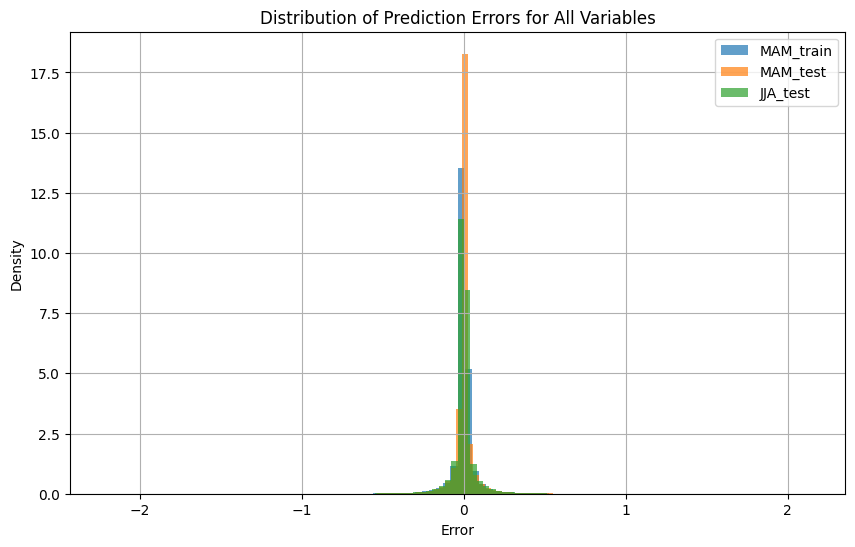

In [7]:

# Plot distribution of errors for all variables
plt.figure(figsize=(10, 6))
for key, result in results.items():
    predictions = result['predictions']
    targets = result['targets']
    error = predictions - targets
    plt.hist(error.cpu().numpy().flatten(), bins=100, density=True, alpha=0.7, label=key)
plt.title('Distribution of Prediction Errors for All Variables')
plt.xlabel('Error')
plt.ylabel('Density')
plt.grid()
plt.legend()
plt.show()

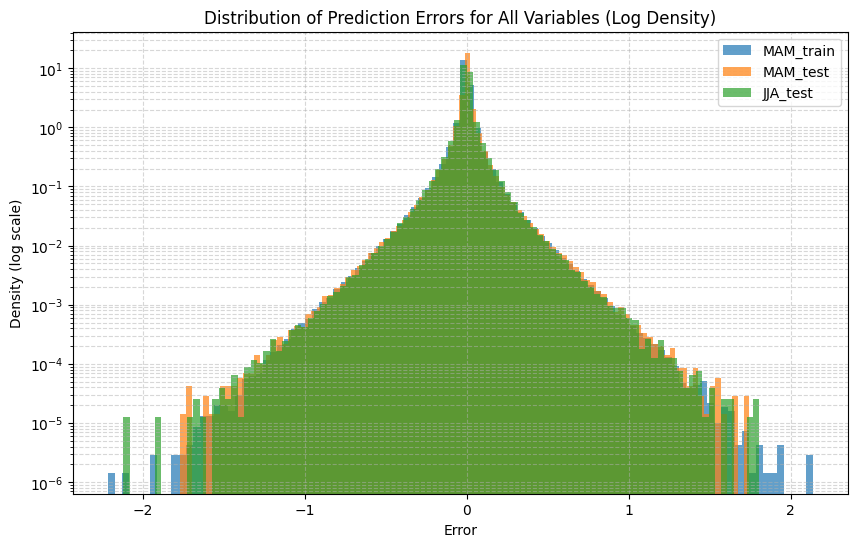

In [8]:
plt.figure(figsize=(10, 6))
for key, result in results.items():
    predictions = result['predictions']
    targets = result['targets']
    error = predictions - targets
    plt.hist(
        error.cpu().numpy().flatten(),
        bins=100,
        density=True,
        alpha=0.7,
        label=key
    )

plt.yscale('log')  # <-- key change
plt.title('Distribution of Prediction Errors for All Variables (Log Density)')
plt.xlabel('Error')
plt.ylabel('Density (log scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


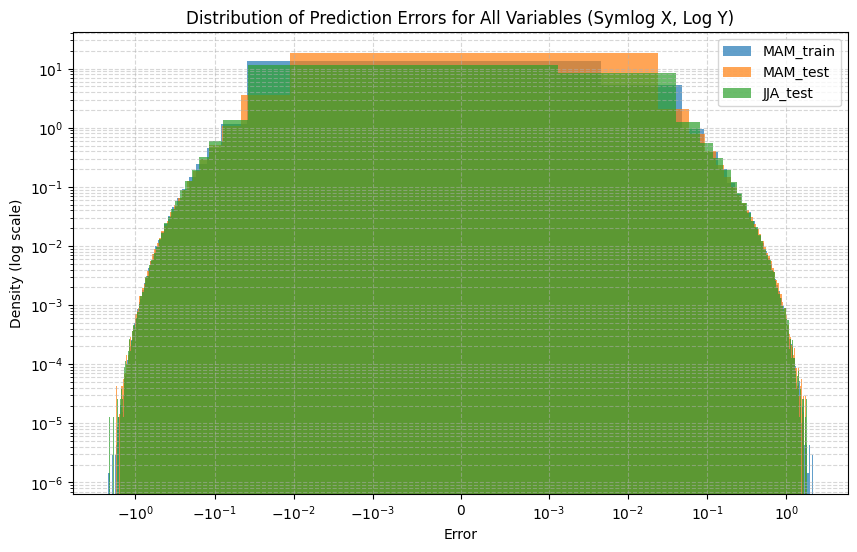

In [9]:
plt.figure(figsize=(10, 6))
for key, result in results.items():
    predictions = result['predictions']
    targets = result['targets']
    error = predictions - targets
    plt.hist(
        error.cpu().numpy().flatten(),
        bins=100,
        density=True,
        alpha=0.7,
        label=key
    )

plt.xscale('symlog', linthresh=1e-3)  # adjust linthresh as needed
plt.yscale('log')
plt.title('Distribution of Prediction Errors for All Variables (Symlog X, Log Y)')
plt.xlabel('Error')
plt.ylabel('Density (log scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()



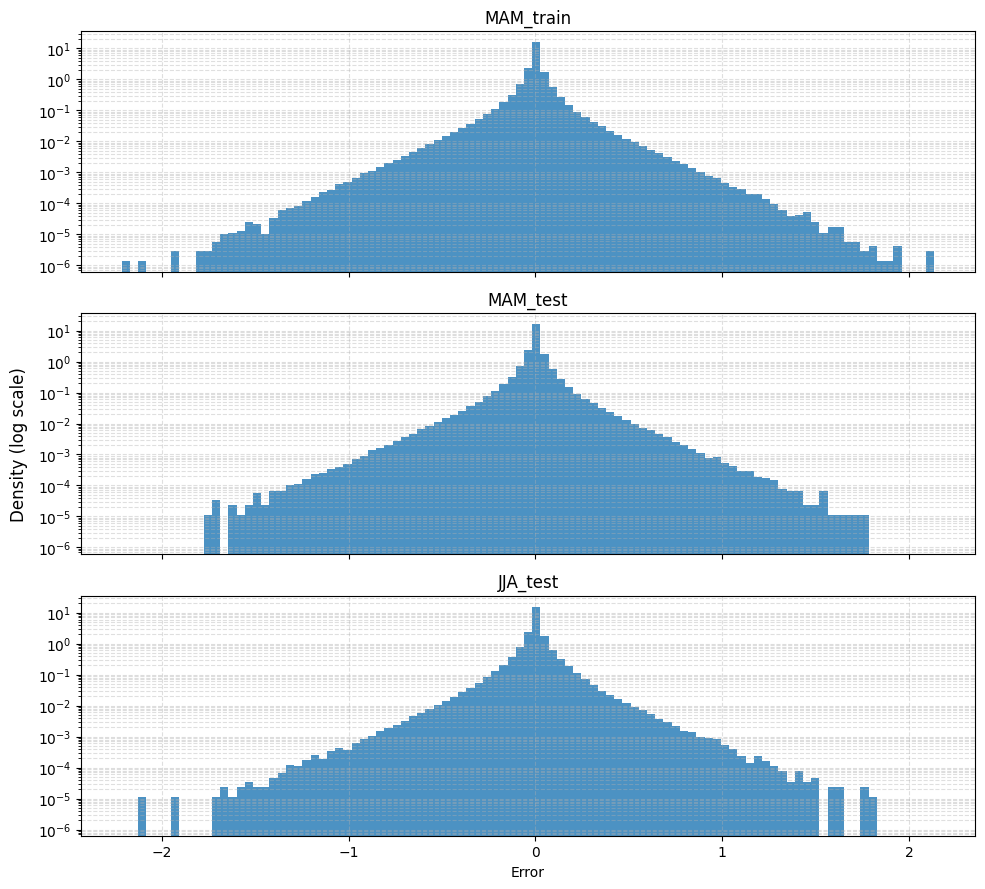

In [10]:
import numpy as np

n = len(results)
fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n), sharex=True, sharey=True)

# Precompute global error range for consistent bins
all_errors = np.concatenate([
    (r['predictions'] - r['targets']).cpu().numpy().flatten()
    for r in results.values()
])

bins = np.linspace(all_errors.min(), all_errors.max(), 100)

for ax, (key, result) in zip(axes, results.items()):
    error = (result['predictions'] - result['targets']).cpu().numpy().flatten()
    ax.hist(error, bins=bins, density=True, alpha=0.8)
    ax.set_yscale('log')
    ax.set_title(key)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Error')
fig.supylabel('Density (log scale)')
plt.tight_layout()
plt.show()



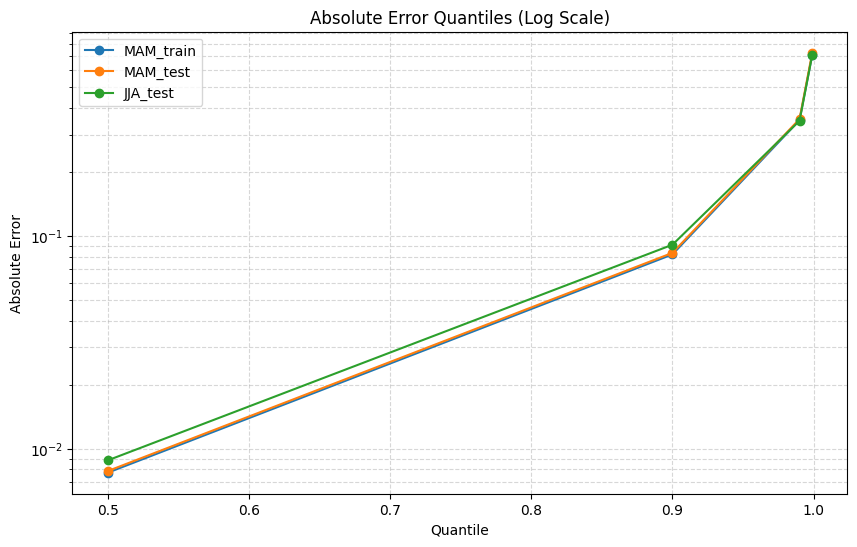

[1.12274718 1.09222182 0.98132428 0.97697164]


In [13]:
quantiles = [0.5, 0.9, 0.99, 0.999]

plt.figure(figsize=(10, 6))

for key, result in results.items():
    error = (result['predictions'] - result['targets']).cpu().numpy().flatten()
    q = np.quantile(np.abs(error), quantiles)
    plt.plot(quantiles, q, marker='o', label=key)

plt.yscale('log')
plt.xlabel('Quantile')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Quantiles (Log Scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()



jja_error = results['JJA_test']['predictions'] - results['JJA_test']['targets']
mam_error = results['MAM_test']['predictions'] - results['MAM_test']['targets']
jja_q = np.quantile(np.abs(jja_error.cpu().numpy().flatten()), quantiles)
mam_q = np.quantile(np.abs(mam_error.cpu().numpy().flatten()), quantiles)
ratio = jja_q / mam_q
print(ratio)

“JJA exhibits consistently larger errors than MAM across the distribution, but the seasonal gap is most pronounced in the bulk and moderate tail (0.5–0.9 quantiles), while the most extreme errors (≥0.99) are comparable across seasons.”

/home/users/bradlesc/projects/ClimSim/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


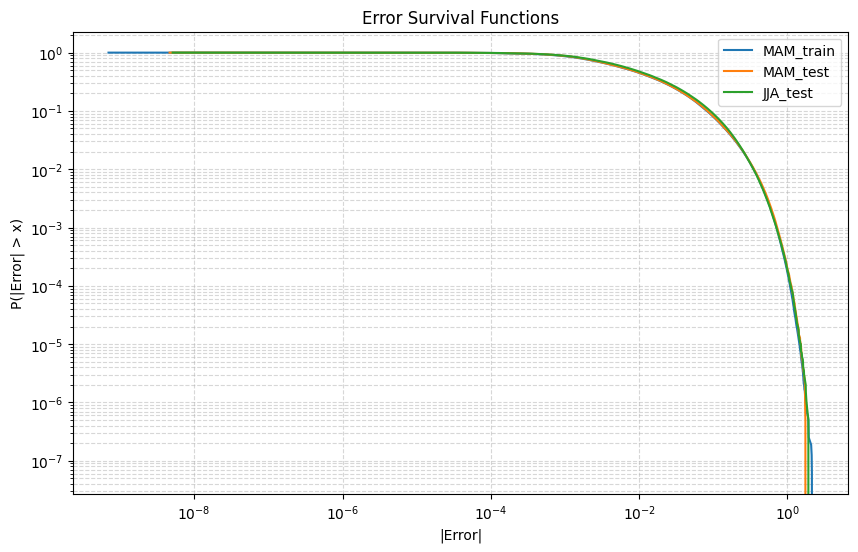

In [12]:
plt.figure(figsize=(10, 6))

for key, result in results.items():
    error = np.abs((result['predictions'] - result['targets']).cpu().numpy().flatten())
    error_sorted = np.sort(error)
    survival = 1.0 - np.arange(1, len(error_sorted) + 1) / len(error_sorted)
    plt.plot(error_sorted, survival, label=key)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('|Error|')
plt.ylabel('P(|Error| > x)')
plt.title('Error Survival Functions')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


Next we want to look at per variable

In [14]:
results['JJA_test']['predictions'].shape #- results['JJA_test']['targets']


torch.Size([20352, 98])

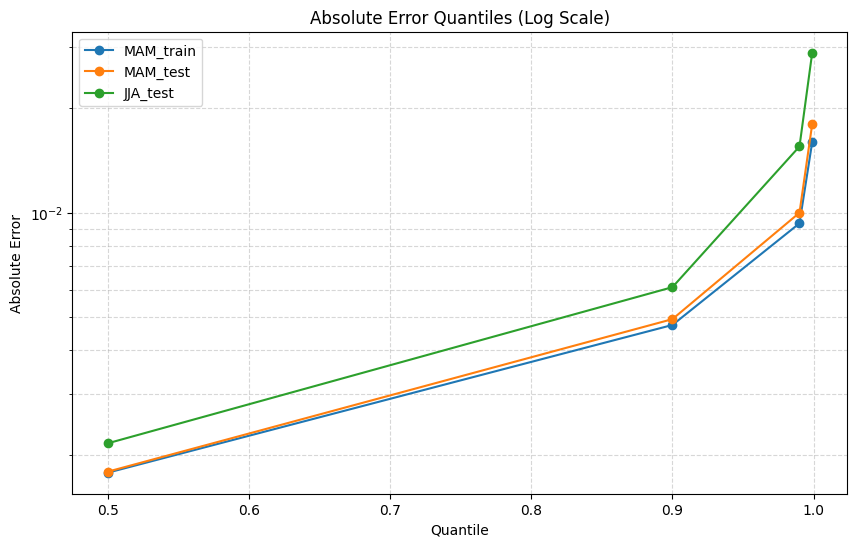

In [ ]:
quantiles = [0.5, 0.9, 0.99, 0.999]
nvar = results['JJA_test']['predictions'].shape[1]
plt.figure(figsize=(10, 6))

for key, result in results.items():
    error = (result['predictions'][:, 0] - result['targets'][:, 0]).cpu().numpy().flatten()
    q = np.quantile(np.abs(error), quantiles)
    plt.plot(quantiles, q, marker='o', label=key)

plt.yscale('log')
plt.xlabel('Quantile')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Quantiles (Log Scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

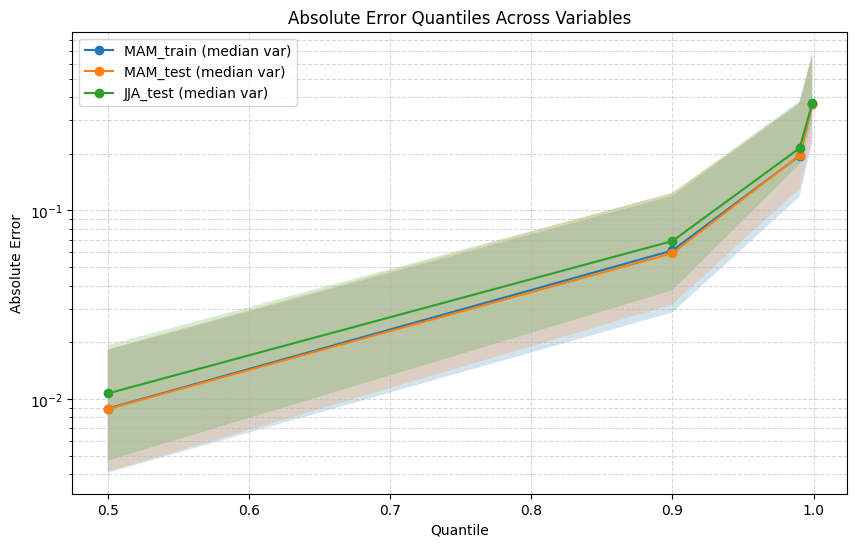

In [16]:
import numpy as np
import matplotlib.pyplot as plt

quantiles = [0.5, 0.9, 0.99, 0.999]
nvar = results['JJA_test']['predictions'].shape[1]

plt.figure(figsize=(10, 6))

for key, result in results.items():
    preds = result['predictions'].cpu().numpy()
    targs = result['targets'].cpu().numpy()

    # shape: (nvar, n_quantiles)
    q_per_var = []

    for i in range(nvar):
        error = np.abs(preds[:, i] - targs[:, i])
        q_per_var.append(np.quantile(error, quantiles))

    q_per_var = np.array(q_per_var)

    # aggregate across variables
    q_median = np.median(q_per_var, axis=0)
    q_lo = np.percentile(q_per_var, 25, axis=0)
    q_hi = np.percentile(q_per_var, 75, axis=0)

    plt.plot(quantiles, q_median, marker='o', label=f'{key} (median var)')
    plt.fill_between(
        quantiles, q_lo, q_hi, alpha=0.2
    )

plt.yscale('log')
plt.xlabel('Quantile')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Quantiles Across Variables')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


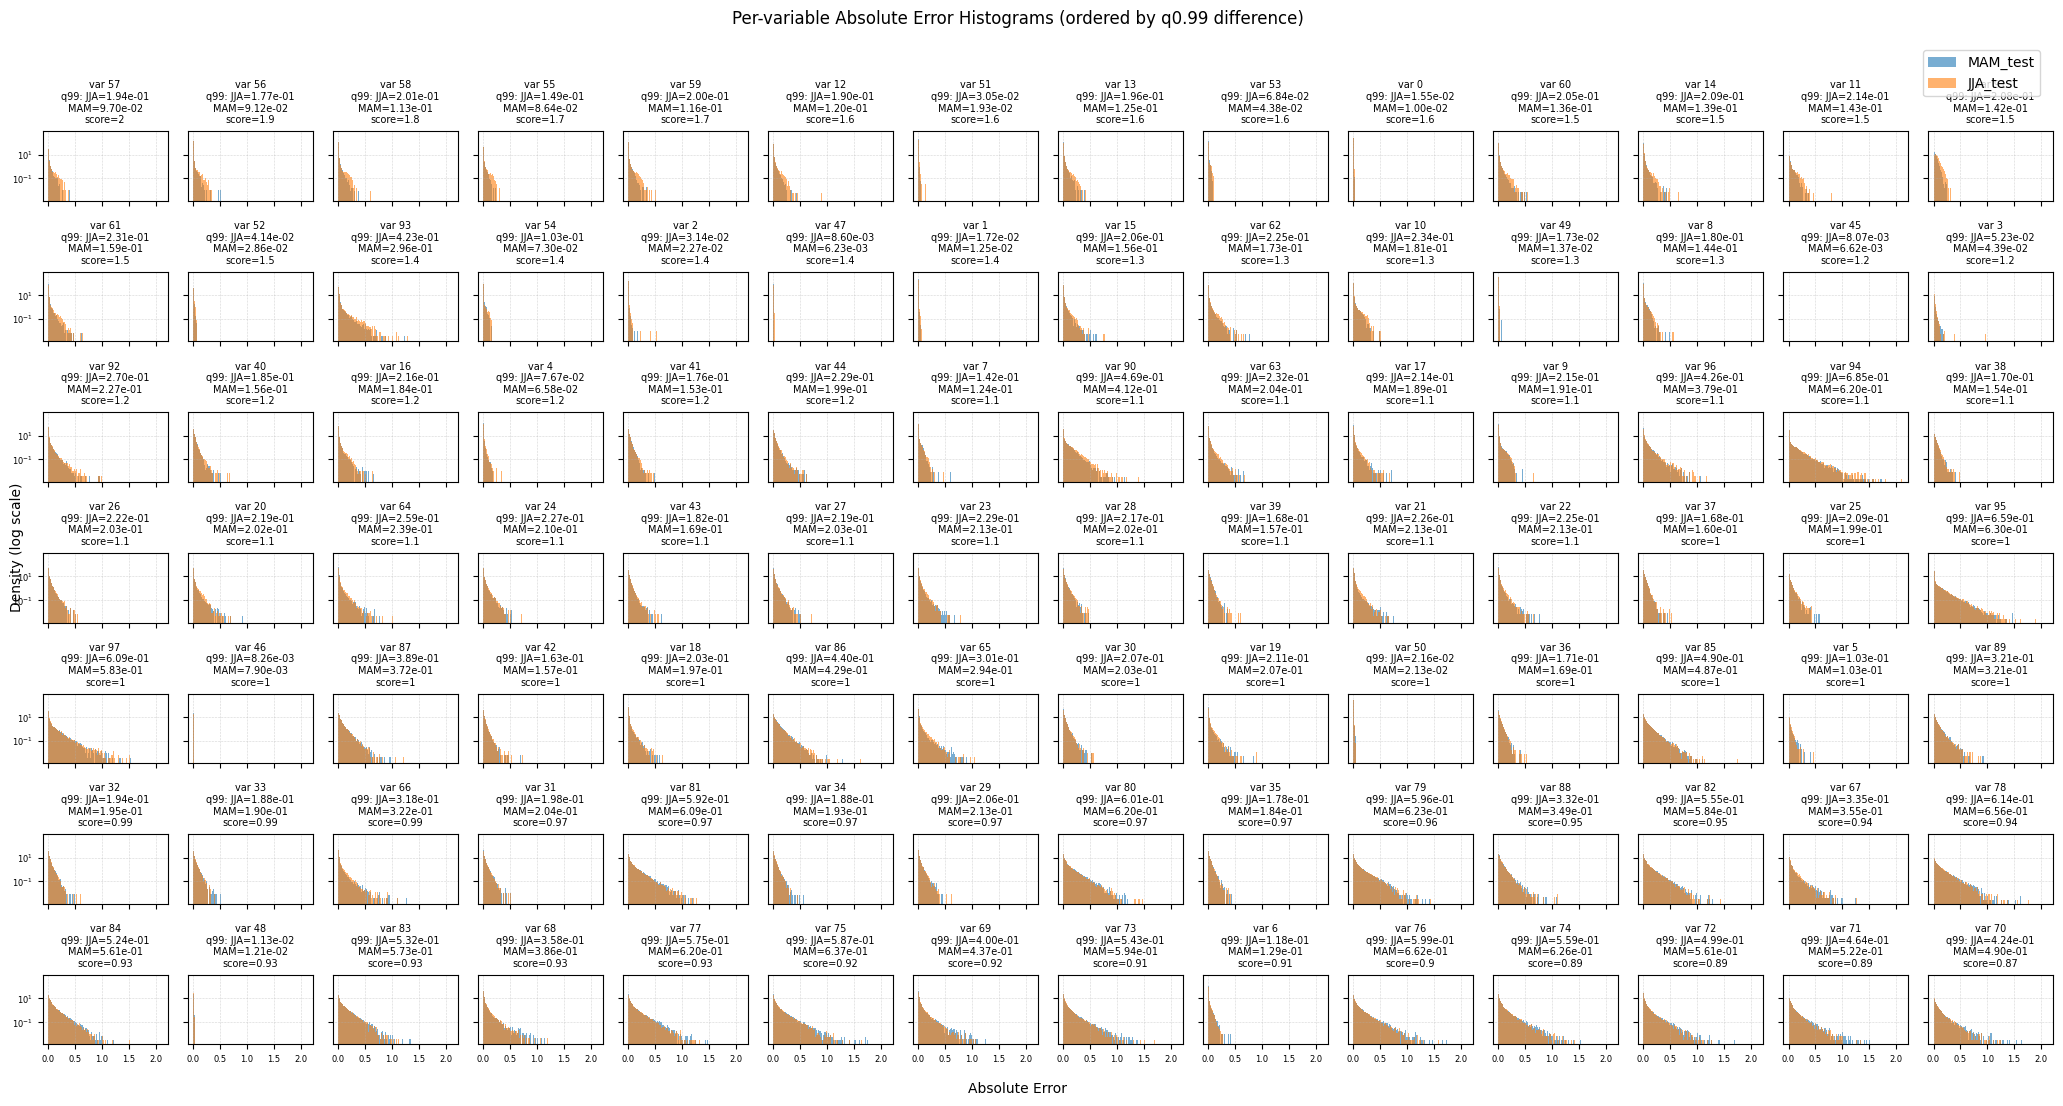

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters you can tune:
quantile_for_sort = 0.99   # which quantile to use when measuring JJA vs MAM difference
ncols = 14                 # grid layout (14 x 7 = 98)
nrows = 7
bins = 100                 # histogram bins

# --- extract arrays (move to numpy; shape: (nsamples, nvar)) ---
preds_jja = results['JJA_test']['predictions'].cpu().numpy()
targs_jja = results['JJA_test']['targets'].cpu().numpy()

preds_mam = results['MAM_test']['predictions'].cpu().numpy()
targs_mam = results['MAM_test']['targets'].cpu().numpy()

nsamps, nvar = preds_jja.shape
assert nvar == preds_mam.shape[1] == targs_jja.shape[1] == targs_mam.shape[1], "Mismatch in variable count"

# --- compute per-variable absolute-error quantiles for each season ---
jja_q = np.zeros(nvar)
mam_q = np.zeros(nvar)

for i in range(nvar):
    err_jja = np.abs(preds_jja[:, i] - targs_jja[:, i])
    err_mam = np.abs(preds_mam[:, i] - targs_mam[:, i])
    jja_q[i] = np.quantile(err_jja, quantile_for_sort)
    mam_q[i] = np.quantile(err_mam, quantile_for_sort)

# difference score (absolute or relative). I'll use relative ratio where defined, fallback to absolute diff:
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = jja_q / mam_q
    # define score: if mam_q==0, use absolute difference
    score = np.where(mam_q > 0, ratio, jja_q - mam_q)

# sort indices by descending "score" (largest difference first)
order = np.argsort(-score)

# --- prepare plotting ---
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.5, nrows * 1.6), sharex=True, sharey=True)
axes = axes.flatten()

# compute common bin edges per variable pair to keep histograms fair
# (we will compute each variable's combined min/max and create bins per-variable)
for rank, idx in enumerate(order):
    ax = axes[rank]

    # errors for this variable
    err_jja = (preds_jja[:, idx] - targs_jja[:, idx]).flatten()
    err_mam = (preds_mam[:, idx] - targs_mam[:, idx]).flatten()

    # use absolute errors for quantile comparisons, but show signed error histogram to see direction if desired
    # we'll plot absolute-error histograms (density) for clarity
    abs_jja = np.abs(err_jja)
    abs_mam = np.abs(err_mam)

    # per-variable bins (shared between the two seasons)
    vmin = min(abs_jja.min(), abs_mam.min())
    vmax = max(abs_jja.max(), abs_mam.max())
    if vmin == vmax:
        # degenerate: create a tiny range
        vmin = 0.0
        vmax = vmax + 1e-6
    bin_edges = np.linspace(vmin, vmax, bins)

    ax.hist(abs_mam, bins=bin_edges, density=True, alpha=0.6, label='MAM_test', linewidth=0)
    ax.hist(abs_jja, bins=bin_edges, density=True, alpha=0.6, label='JJA_test', linewidth=0)

    ax.set_yscale('log')
    ax.grid(True, which='both', linestyle=':', linewidth=0.4)
    # annotate: variable id and metric
    txt = f'var {idx}\nq{int(quantile_for_sort*100)}: JJA={jja_q[idx]:.2e}\nMAM={mam_q[idx]:.2e}\nscore={score[idx]:.2g}'
    ax.set_title(txt, fontsize=7)
    ax.tick_params(axis='both', which='major', labelsize=6)

# hide any unused axes (if any)
for k in range(len(order), len(axes)):
    axes[k].axis('off')

# common labels and legend
fig.supylabel('Density (log scale)', fontsize=10)
fig.supxlabel('Absolute Error', fontsize=10)

# place a single legend (one per figure)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.95))

plt.suptitle(f'Per-variable Absolute Error Histograms (ordered by q{quantile_for_sort} difference)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Optional: save
# fig.savefig('per_variable_error_histograms_ordered.png', dpi=200, bbox_inches='tight')


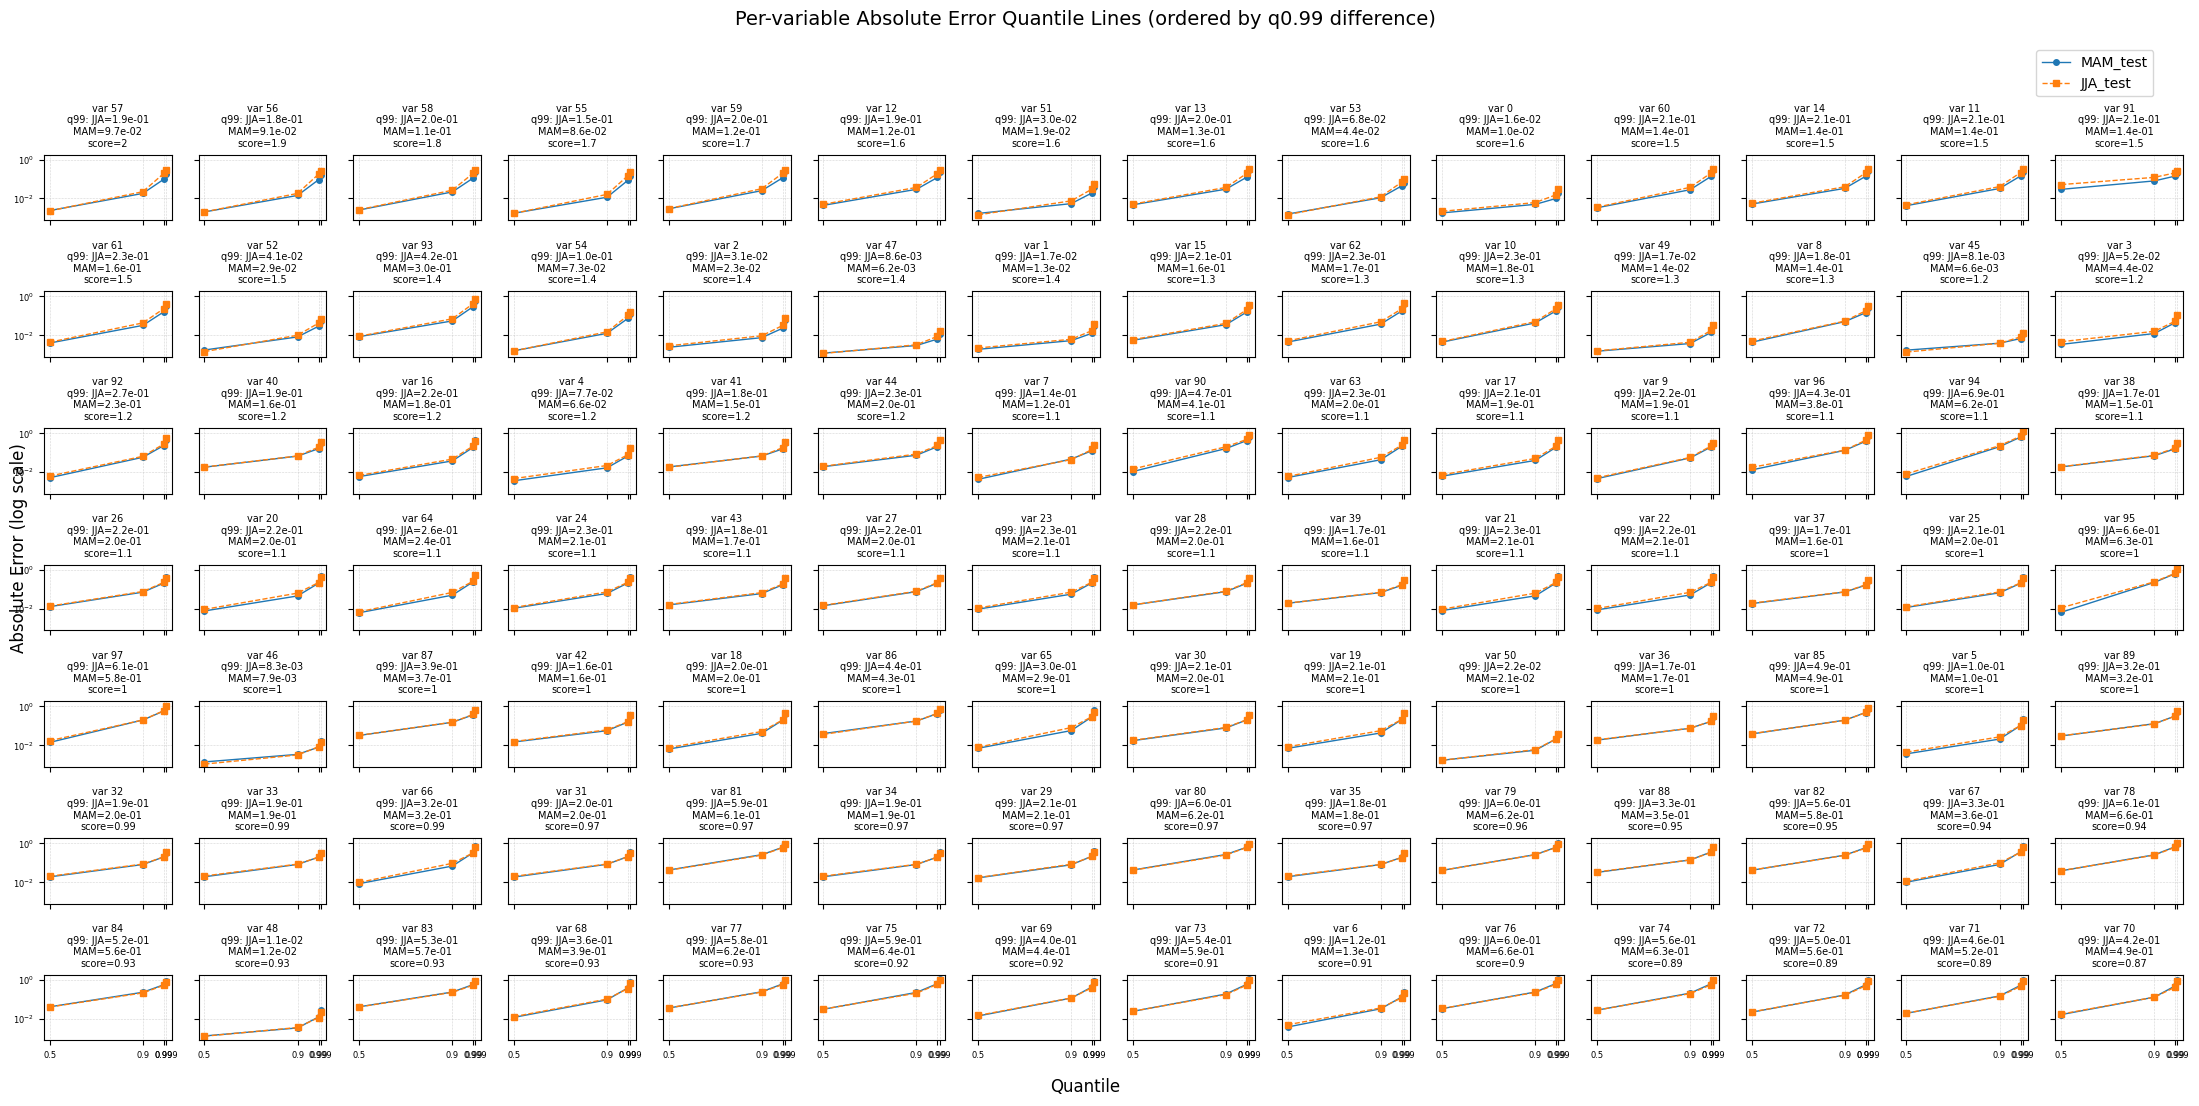

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
quantiles = [0.5, 0.9, 0.99, 0.999]
quantile_for_sort = 0.99  # which quantile to use for ordering variables
ncols = 14                 # grid layout: 14 x 7 = 98
nrows = 7
markersize = 4

# --- load arrays (nsamples, nvar) ---
preds_jja = results['JJA_test']['predictions'].cpu().numpy()
targs_jja = results['JJA_test']['targets'].cpu().numpy()

preds_mam = results['MAM_test']['predictions'].cpu().numpy()
targs_mam = results['MAM_test']['targets'].cpu().numpy()

nsamps, nvar = preds_jja.shape
assert nvar == preds_mam.shape[1] == targs_jja.shape[1] == targs_mam.shape[1], "Mismatch in variable count"
assert nrows * ncols >= nvar, "Grid too small for number of variables"

# --- compute quantiles per variable for each season (absolute errors) ---
qvals_jja = np.zeros((nvar, len(quantiles)))
qvals_mam = np.zeros((nvar, len(quantiles)))

for i in range(nvar):
    abs_jja = np.abs(preds_jja[:, i] - targs_jja[:, i])
    abs_mam = np.abs(preds_mam[:, i] - targs_mam[:, i])
    qvals_jja[i, :] = np.quantile(abs_jja, quantiles)
    qvals_mam[i, :] = np.quantile(abs_mam, quantiles)

# --- compute sorting metric (ratio where possible, fallback to absolute diff) ---
# find index of quantile_for_sort in quantiles (or nearest)
try:
    sort_idx = quantiles.index(quantile_for_sort)
except ValueError:
    # if not exactly present, find nearest quantile index
    sort_idx = int(np.argmin(np.abs(np.array(quantiles) - quantile_for_sort)))

jja_q = qvals_jja[:, sort_idx]
mam_q = qvals_mam[:, sort_idx]

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(mam_q > 0, jja_q / mam_q, np.nan)
# define score: prefer ratio (values >1 mean JJA larger), but where mam_q==0 use absolute diff
score = np.where(np.isfinite(ratio), ratio, jja_q - mam_q)

# sort descending by difference (largest first)
order = np.argsort(-score)

# --- plotting ---
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 1.6), sharex=True, sharey=True)
axes = axes.flatten()

x = quantiles  # x-axis positions

for rank, idx in enumerate(order):
    if rank >= nrows * ncols:
        break
    ax = axes[rank]

    # plot quantile lines
    ax.plot(x, qvals_mam[idx, :], marker='o', linestyle='-', linewidth=1, markersize=markersize, label='MAM_test')
    ax.plot(x, qvals_jja[idx, :], marker='s', linestyle='--', linewidth=1, markersize=markersize, label='JJA_test')

    ax.set_yscale('log')
    ax.set_xscale('linear')  # quantiles are on linear axis
    ax.set_xticks(x)
    ax.set_xticklabels([str(q) for q in quantiles], fontsize=6)
    ax.tick_params(axis='y', labelsize=6)
    ax.grid(True, which='both', linestyle=':', linewidth=0.4)

    # annotate with index and sorting metric
    title = f'var {idx}\nq{int(quantiles[sort_idx]*100)}: JJA={jja_q[idx]:.1e}\nMAM={mam_q[idx]:.1e}\nscore={score[idx]:.2g}'
    ax.set_title(title, fontsize=7)

# hide any unused axes
for k in range(nvar, len(axes)):
    axes[k].axis('off')

# shared labels and legend
fig.supylabel('Absolute Error (log scale)', fontsize=12)
fig.supxlabel('Quantile', fontsize=12)

# single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95))

plt.suptitle(f'Per-variable Absolute Error Quantile Lines (ordered by q{quantiles[sort_idx]} difference)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


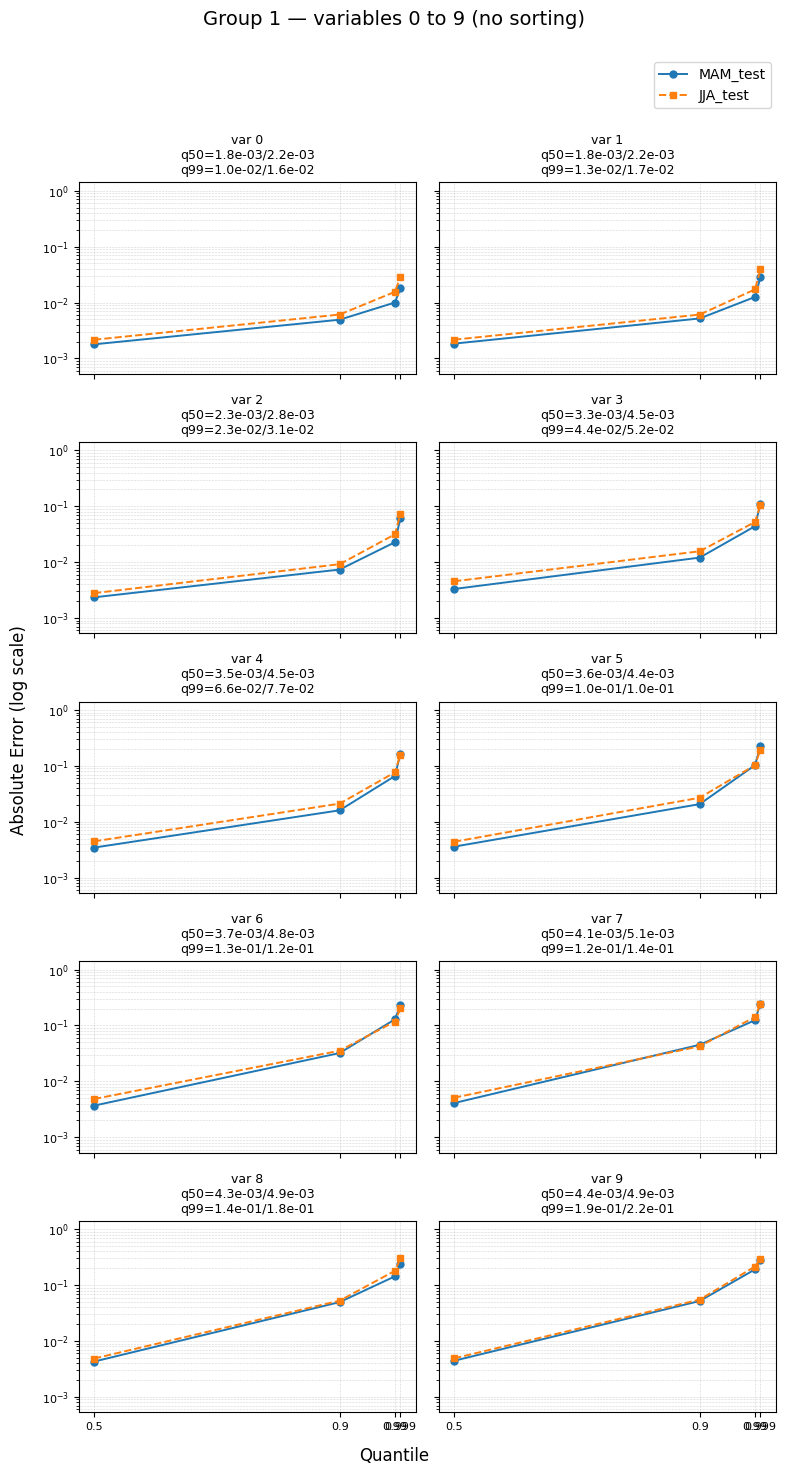

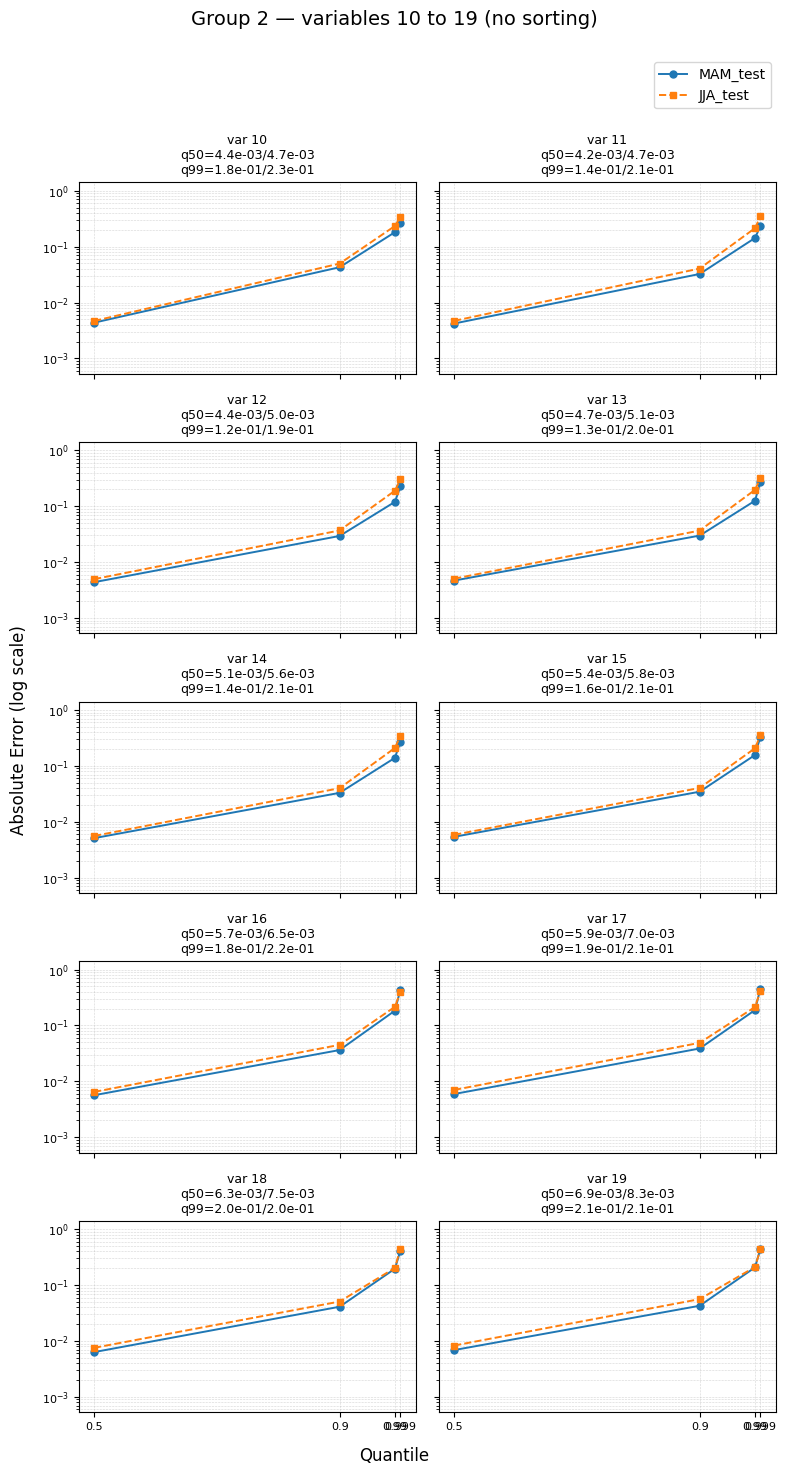

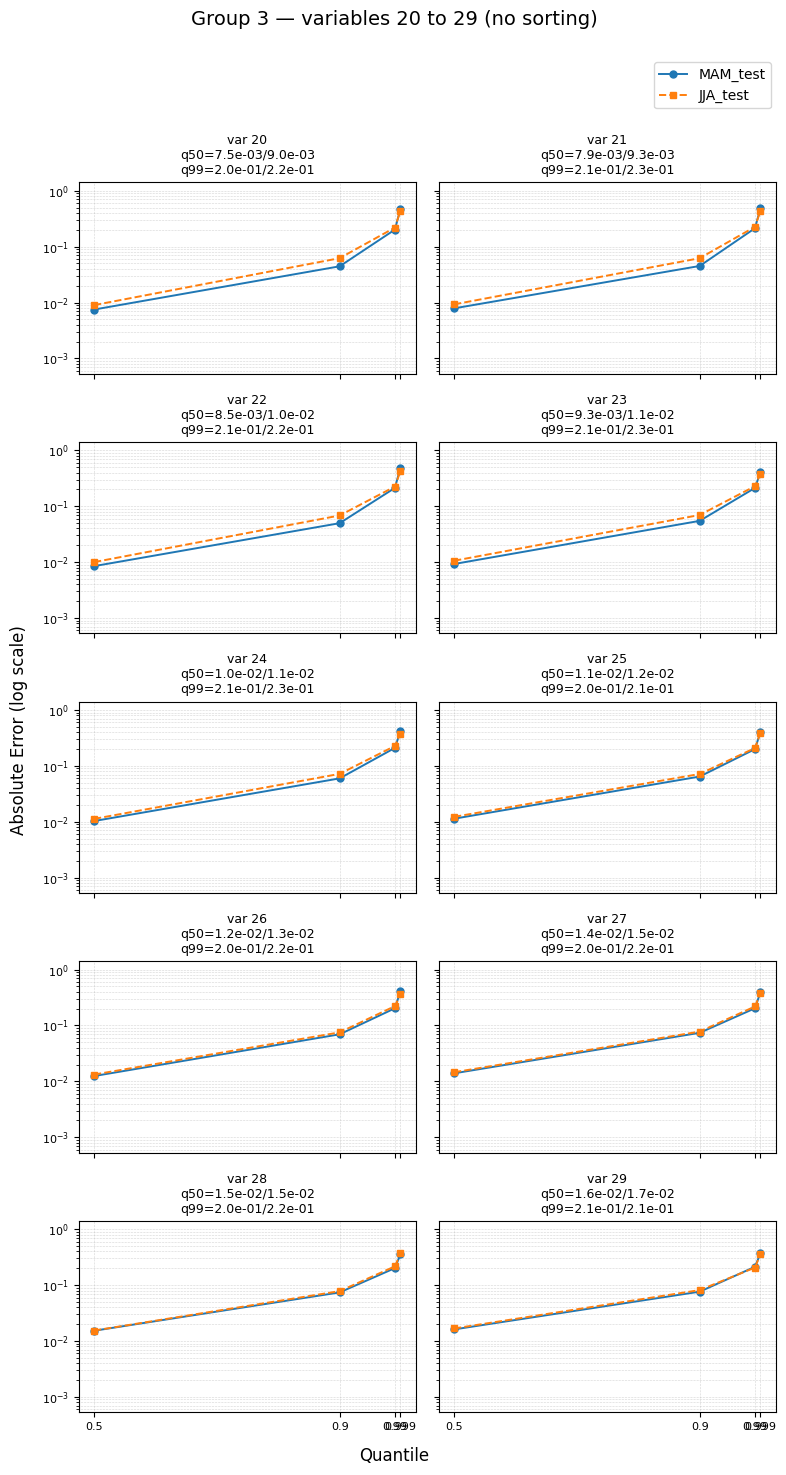

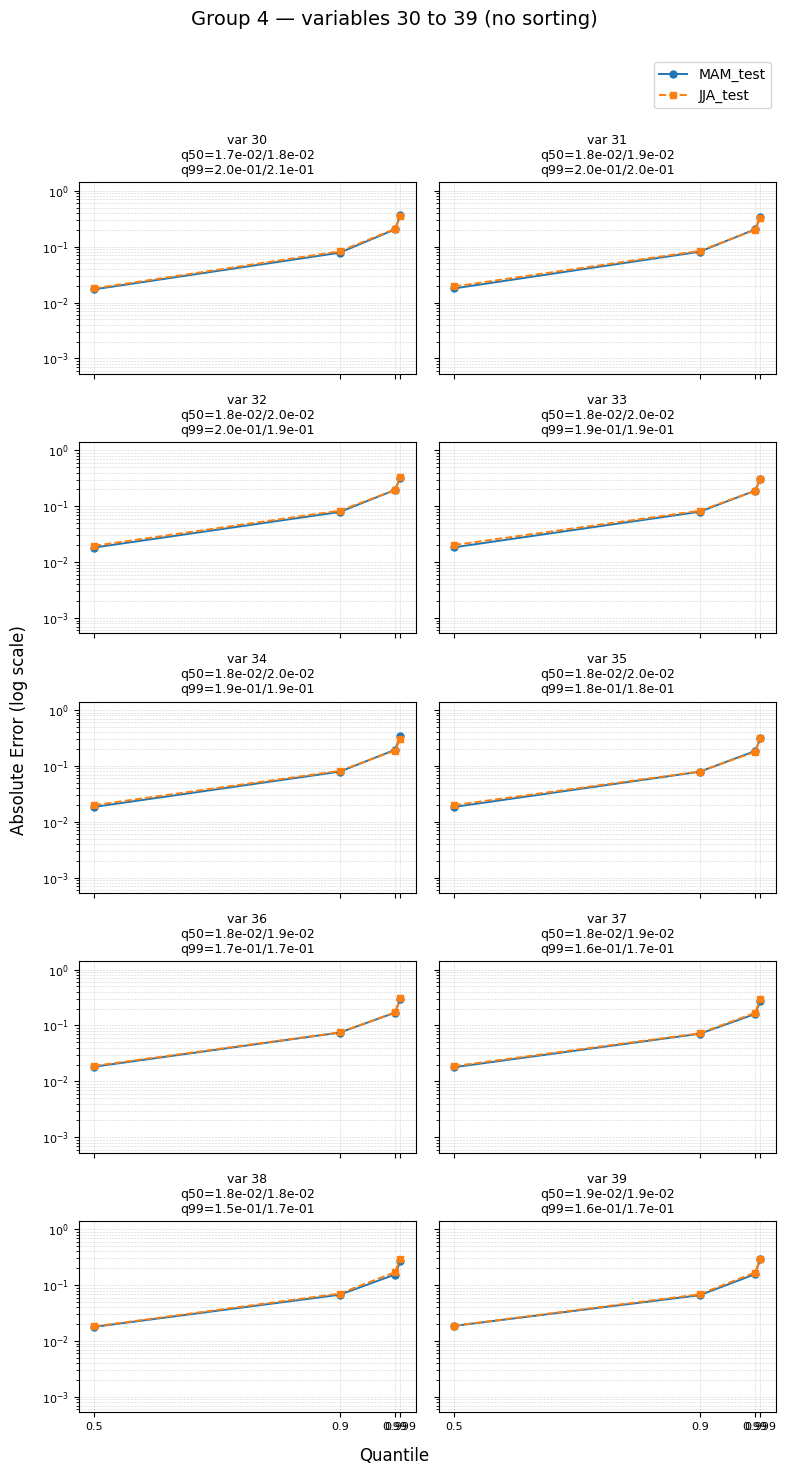

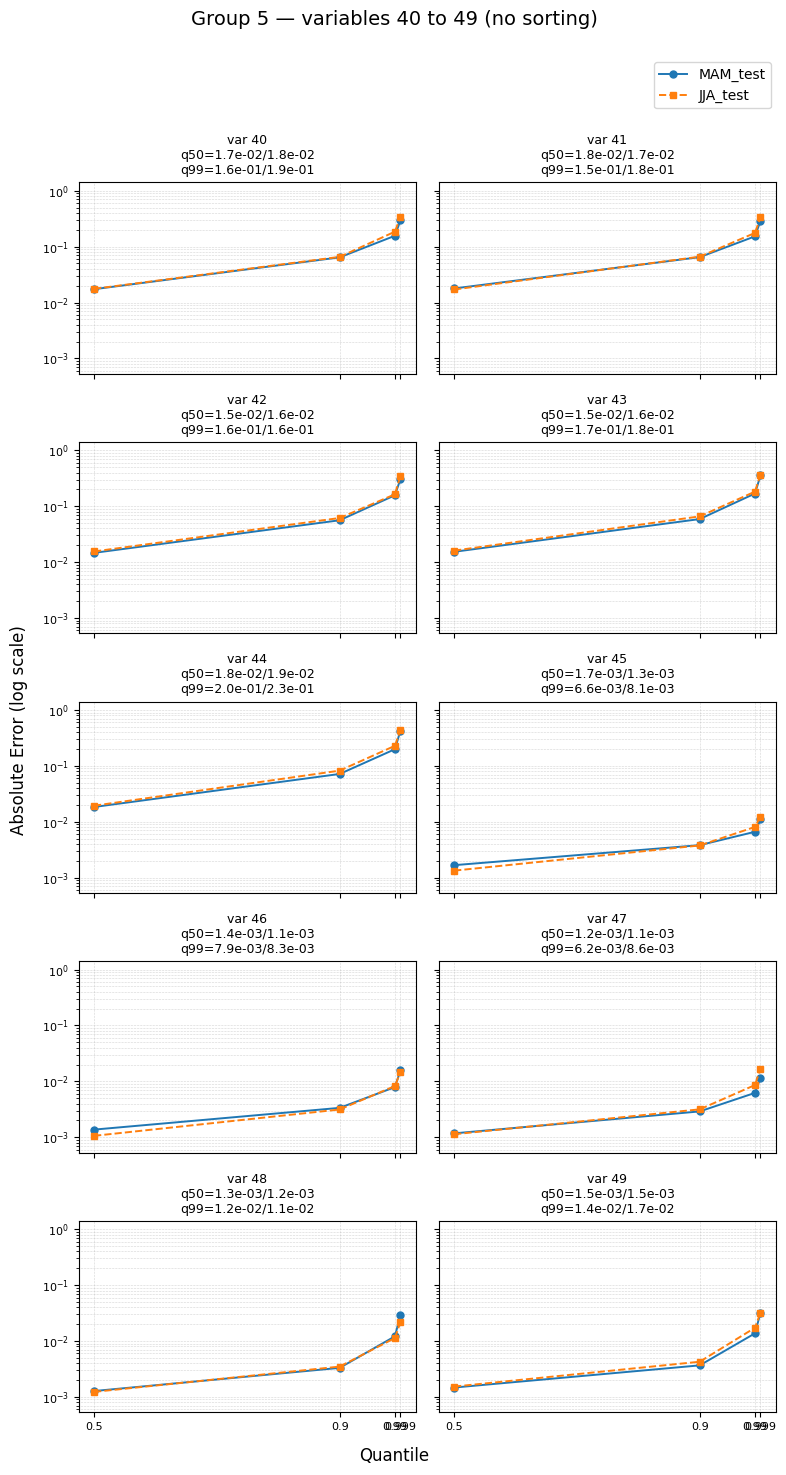

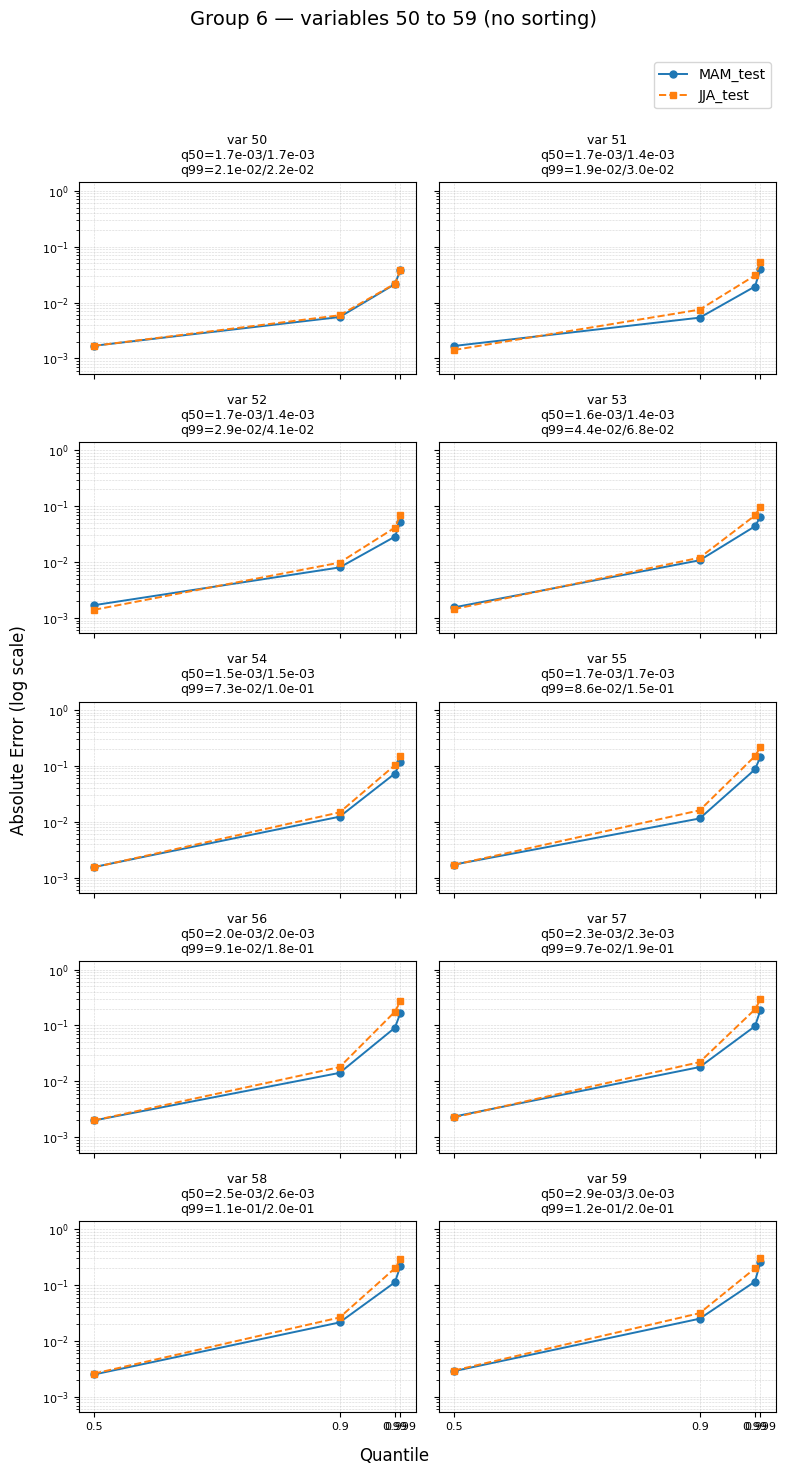

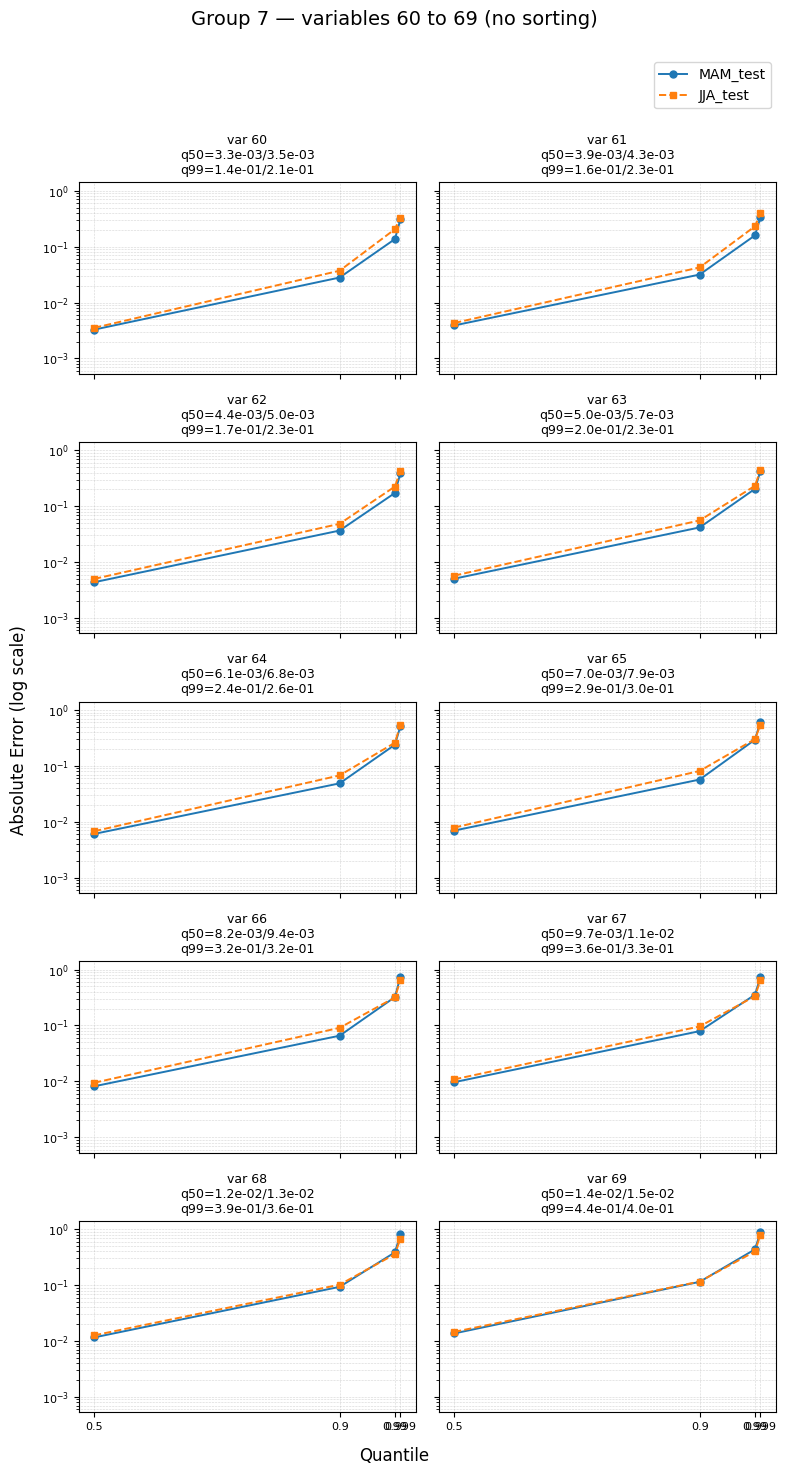

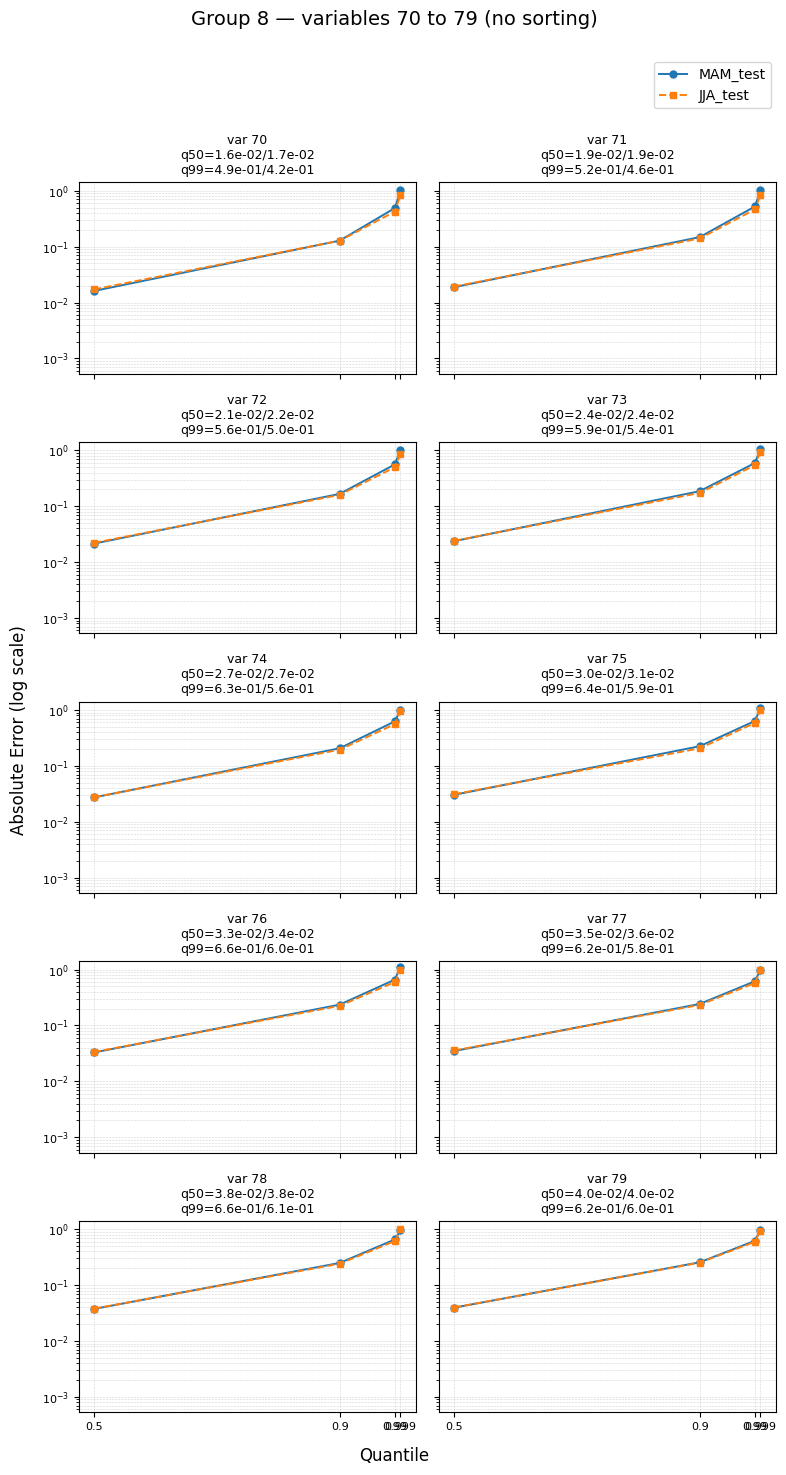

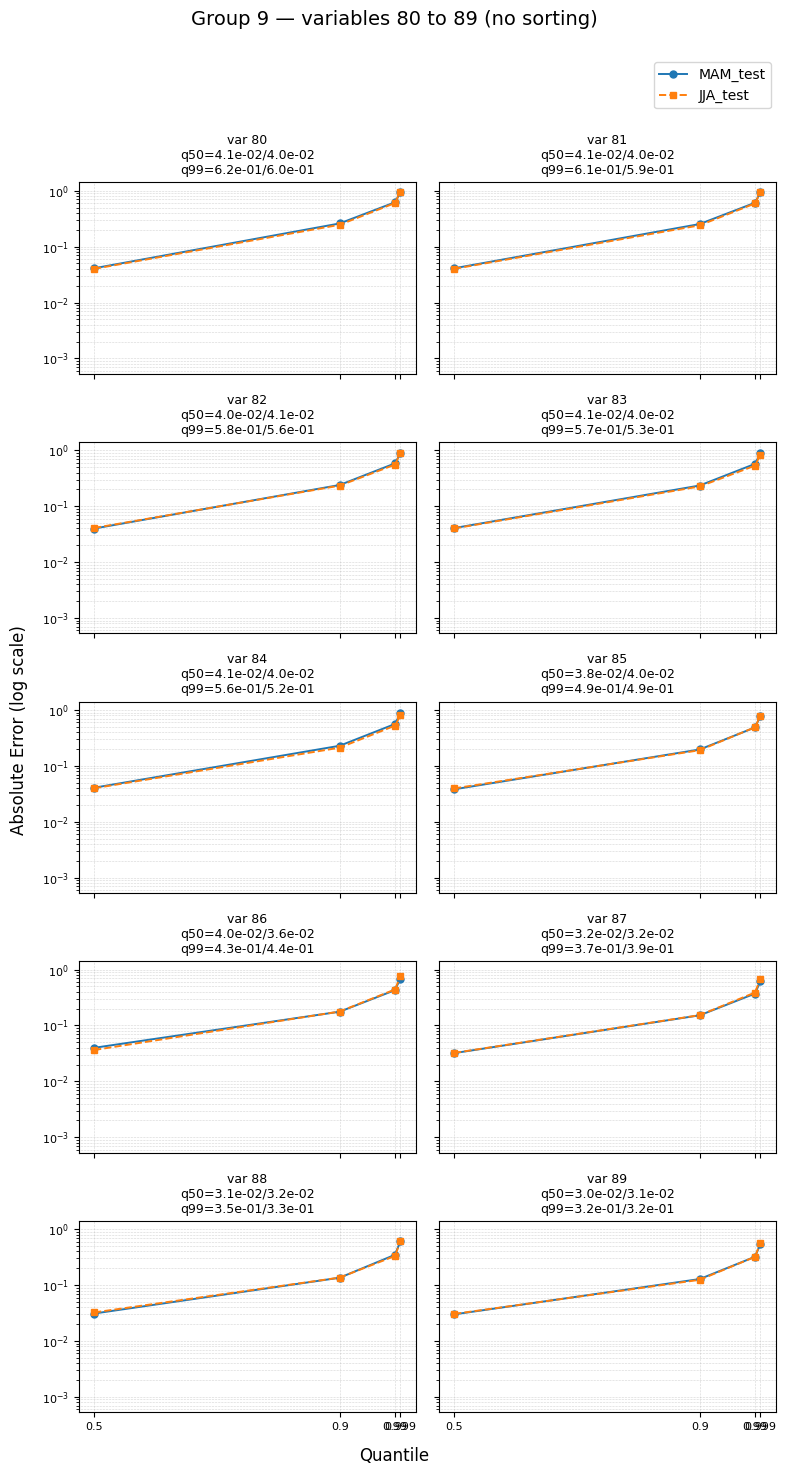

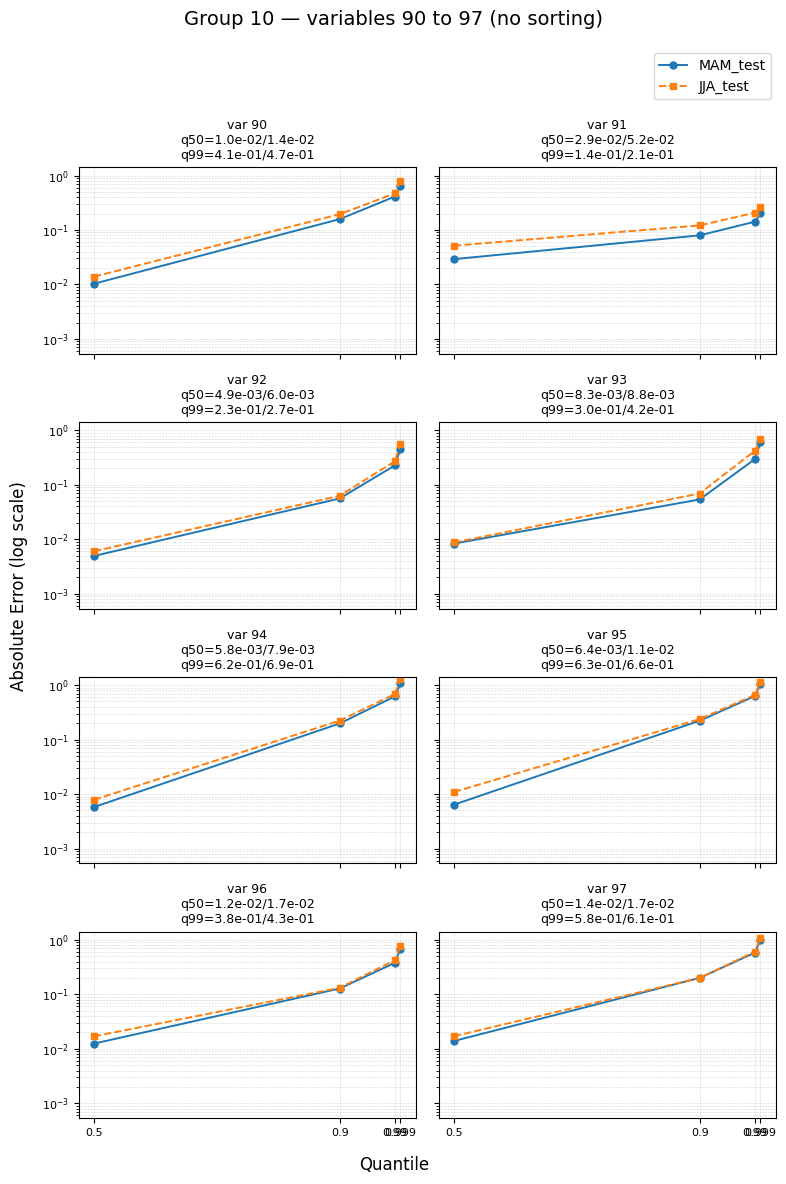

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------- User params ----------
quantiles = [0.5, 0.9, 0.99, 0.999]   # quantiles to plot on x-axis
markersize = 5
groups = 10  # produce exactly 10 figures/plots (9*10 + last group)
# ----------------------------------

# load arrays
preds_jja = results['JJA_test']['predictions'].cpu().numpy()  # shape (nsamps, nvar)
targs_jja = results['JJA_test']['targets'].cpu().numpy()
preds_mam = results['MAM_test']['predictions'].cpu().numpy()
targs_mam = results['MAM_test']['targets'].cpu().numpy()

nsamps, nvar = preds_jja.shape
assert nvar == preds_mam.shape[1] == targs_jja.shape[1] == targs_mam.shape[1], "Mismatch in variable count"

# compute quantiles per variable for each season (absolute errors)
qvals_jja = np.zeros((nvar, len(quantiles)))
qvals_mam = np.zeros((nvar, len(quantiles)))
for i in range(nvar):
    abs_jja = np.abs(preds_jja[:, i] - targs_jja[:, i])
    abs_mam = np.abs(preds_mam[:, i] - targs_mam[:, i])
    qvals_jja[i, :] = np.quantile(abs_jja, quantiles)
    qvals_mam[i, :] = np.quantile(abs_mam, quantiles)

# Partition variables into 10 groups: first 9 groups of 10, last group whatever remains (here 8)
base_group_size = nvar // groups  # 9 for 98//10 = 9
remainder = nvar % groups         # 8 for 98%10
# We'll create the first `remainder` groups with (base_group_size+1) to distribute remainder,
# but to match your request of nine 10s and one 8, we instead use 9 groups of 10 and last 8.
# So we'll implement that exact split:
group_sizes = [10]*9 + [nvar - 10*9]  # [10,...,10,8]
assert sum(group_sizes) == nvar

# compute global y-limits (common across all figures)
all_qvals = np.concatenate([qvals_mam.flatten(), qvals_jja.flatten()])
# replace zeros with a tiny positive for y-min calculation because log scale can't have 0
positive_q = all_qvals[all_qvals > 0]
if positive_q.size == 0:
    ymin = 1e-12
else:
    ymin = positive_q.min() * 0.5  # slightly lower than min positive quantile
ymax = all_qvals.max() * 1.1       # a little headroom

# x positions (quantiles)
x = quantiles

start = 0
for fig_idx, gsize in enumerate(group_sizes):
    indices = np.arange(start, start + gsize)
    start += gsize

    ncols = 2
    nrows = math.ceil(gsize / ncols)
    figsize = (8, nrows * 3.0)  # wider to make two-per-row larger

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    # ensure axes is flattened 1D array
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for ax_idx, var_idx in enumerate(indices):
        ax = axes_flat[ax_idx]
        ax.plot(x, qvals_mam[var_idx, :], marker='o', linestyle='-', linewidth=1.4, markersize=markersize, label='MAM_test')
        ax.plot(x, qvals_jja[var_idx, :], marker='s', linestyle='--', linewidth=1.4, markersize=markersize, label='JJA_test')

        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.set_xticks(x)
        ax.set_xticklabels([str(q) for q in quantiles], fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', linestyle=':', linewidth=0.4)

        # annotate with var index and key quantiles (helpful readout)
        title = f'var {var_idx}\nq50={qvals_mam[var_idx,0]:.1e}/{qvals_jja[var_idx,0]:.1e}\nq99={qvals_mam[var_idx,2]:.1e}/{qvals_jja[var_idx,2]:.1e}'
        ax.set_title(title, fontsize=9)

    # turn off unused axes (if any)
    for k in range(gsize, nrows * ncols):
        axes_flat[k].axis('off')

    # shared labels and single legend per figure
    fig.supxlabel('Quantile', fontsize=12)
    fig.supylabel('Absolute Error (log scale)', fontsize=12)
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95))

    fig.suptitle(f'Group {fig_idx+1} — variables {indices[0]} to {indices[-1]} (no sorting)', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


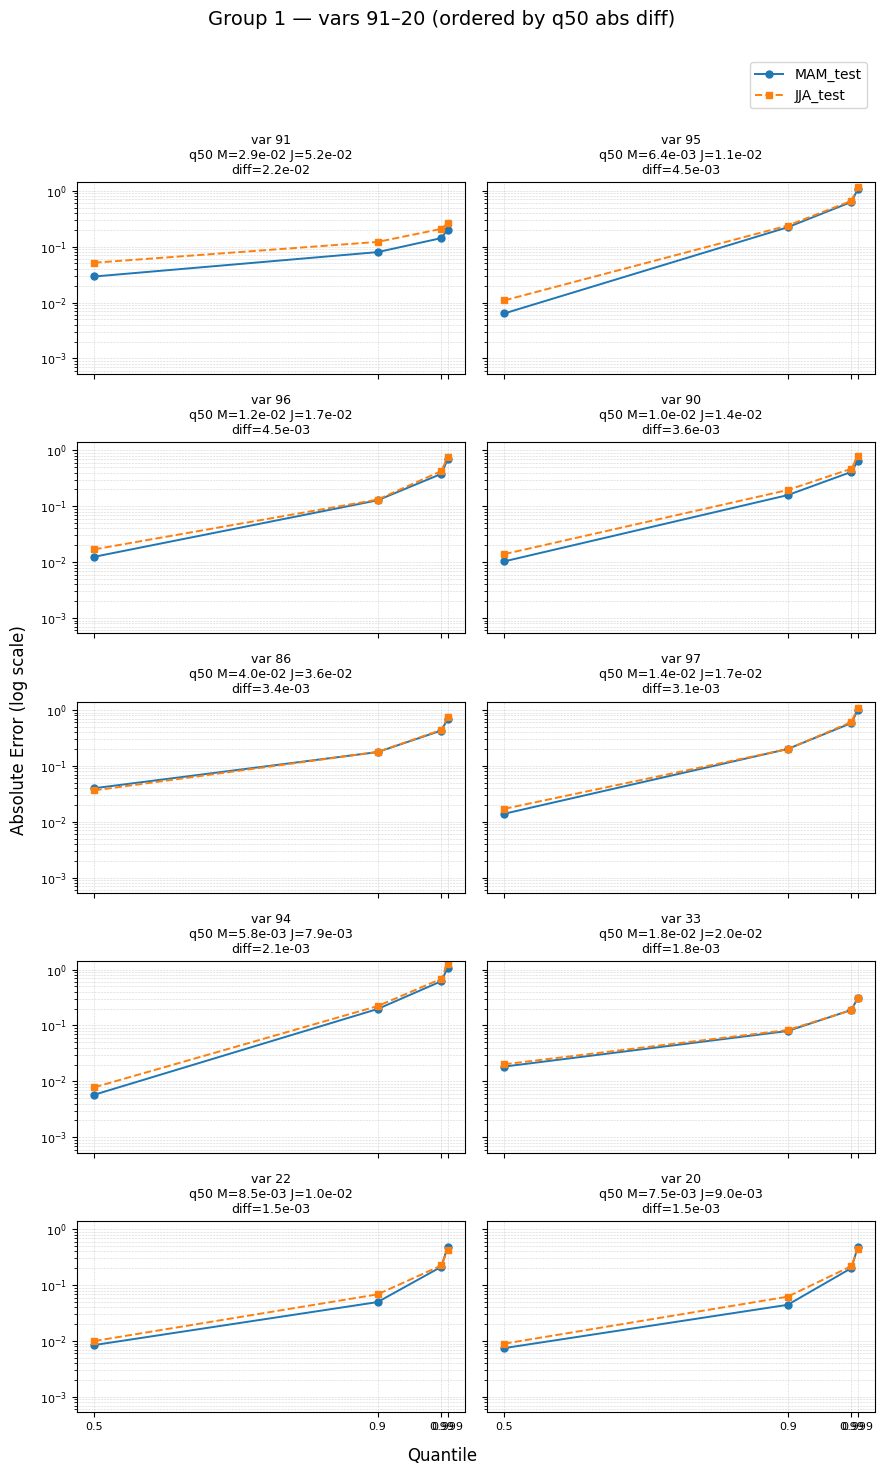

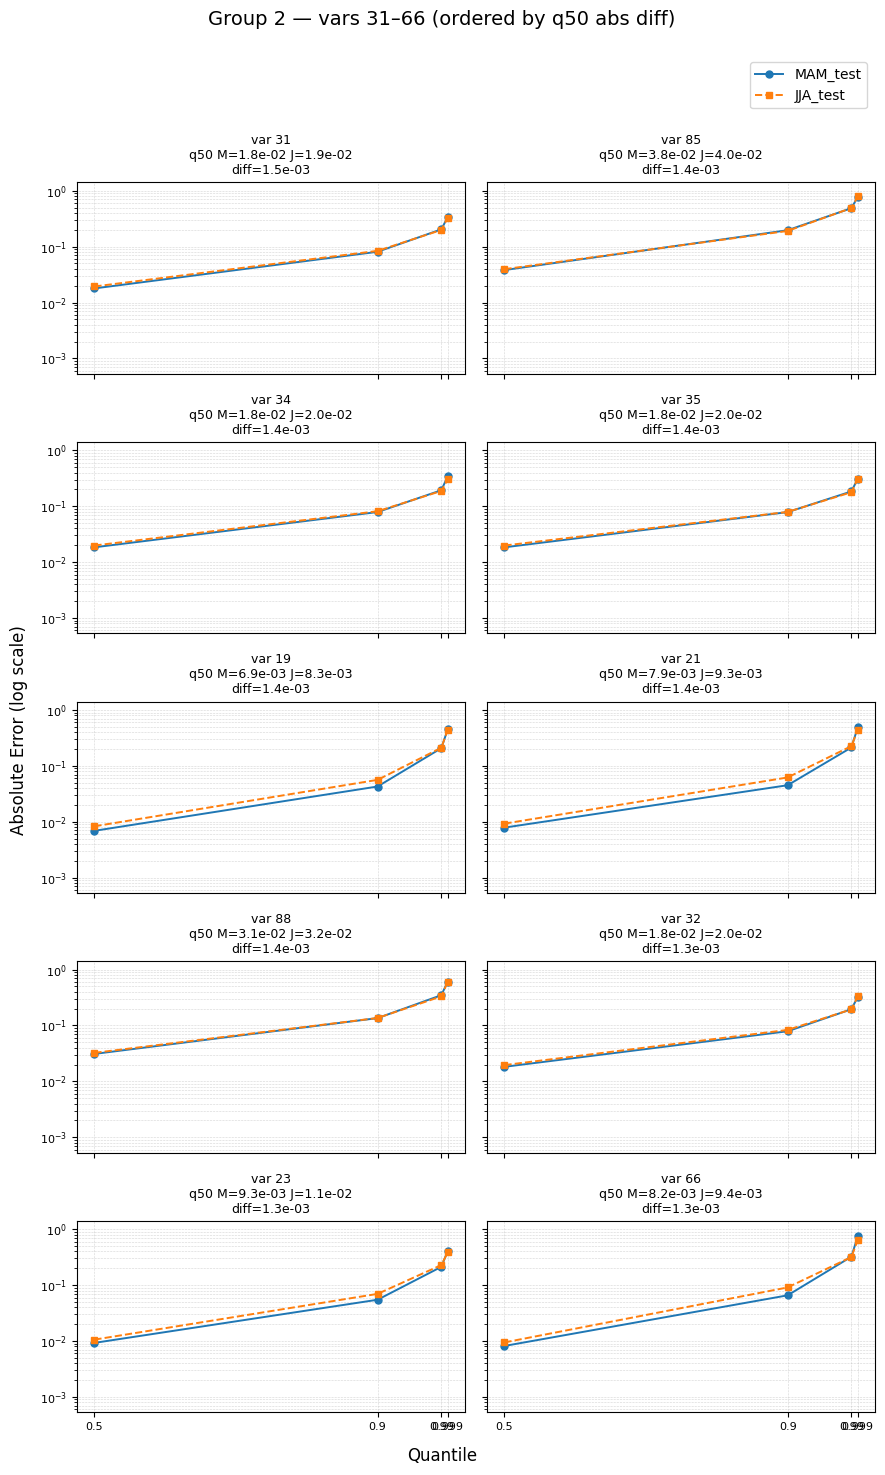

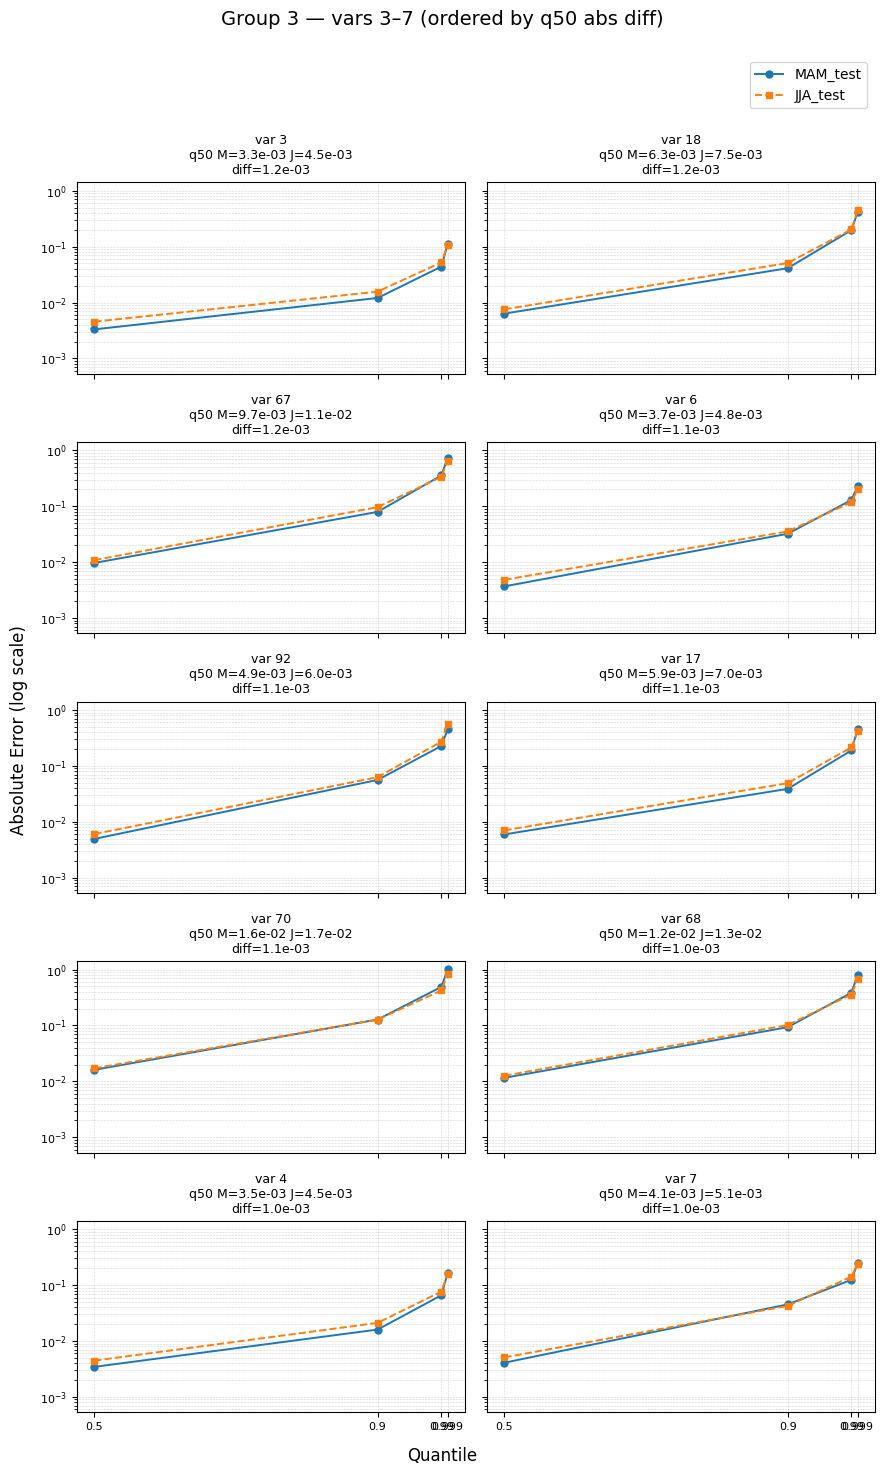

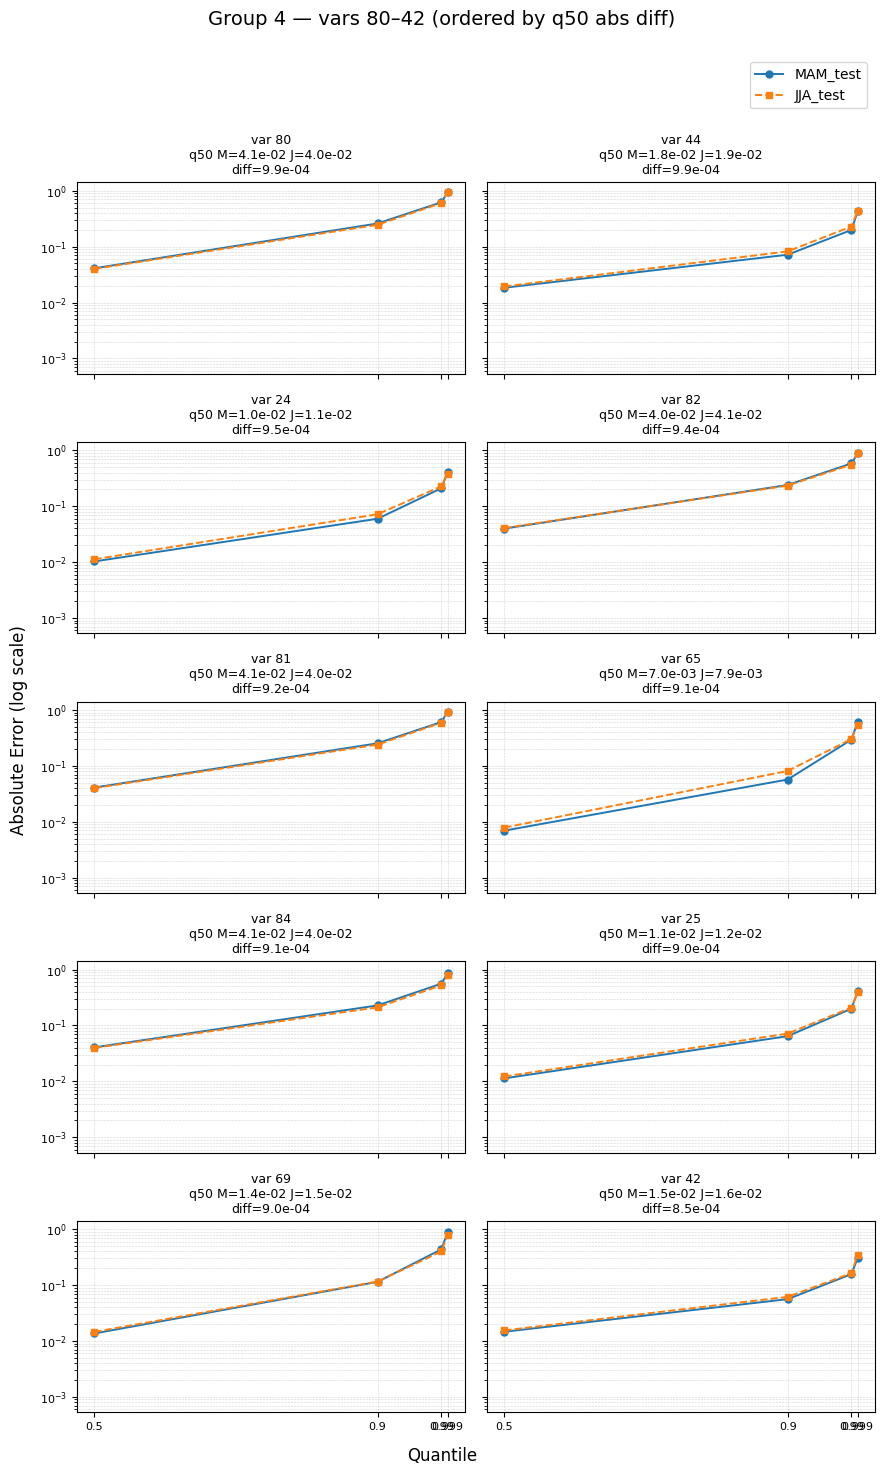

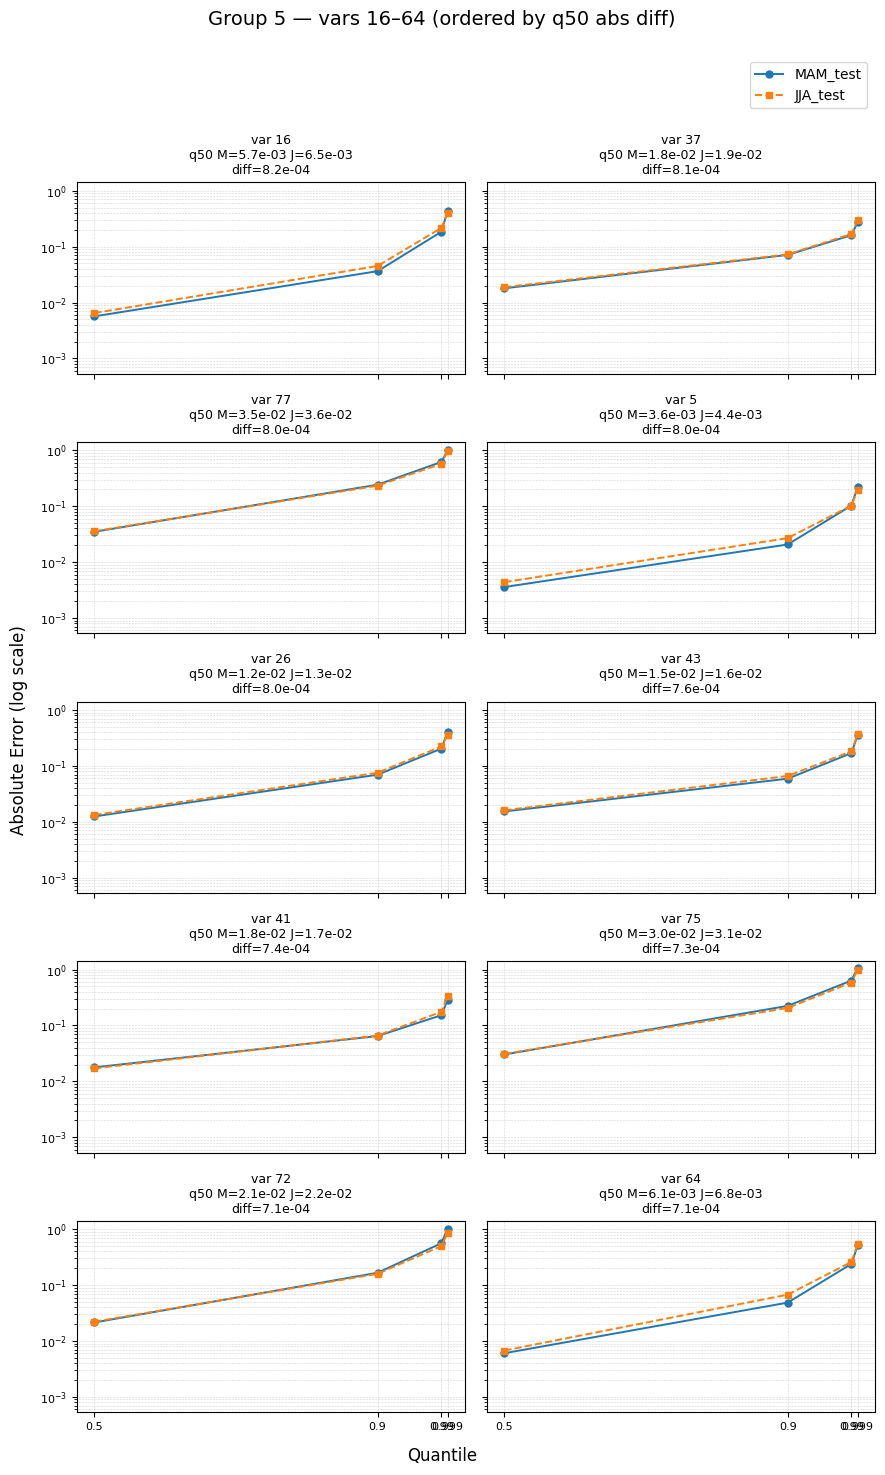

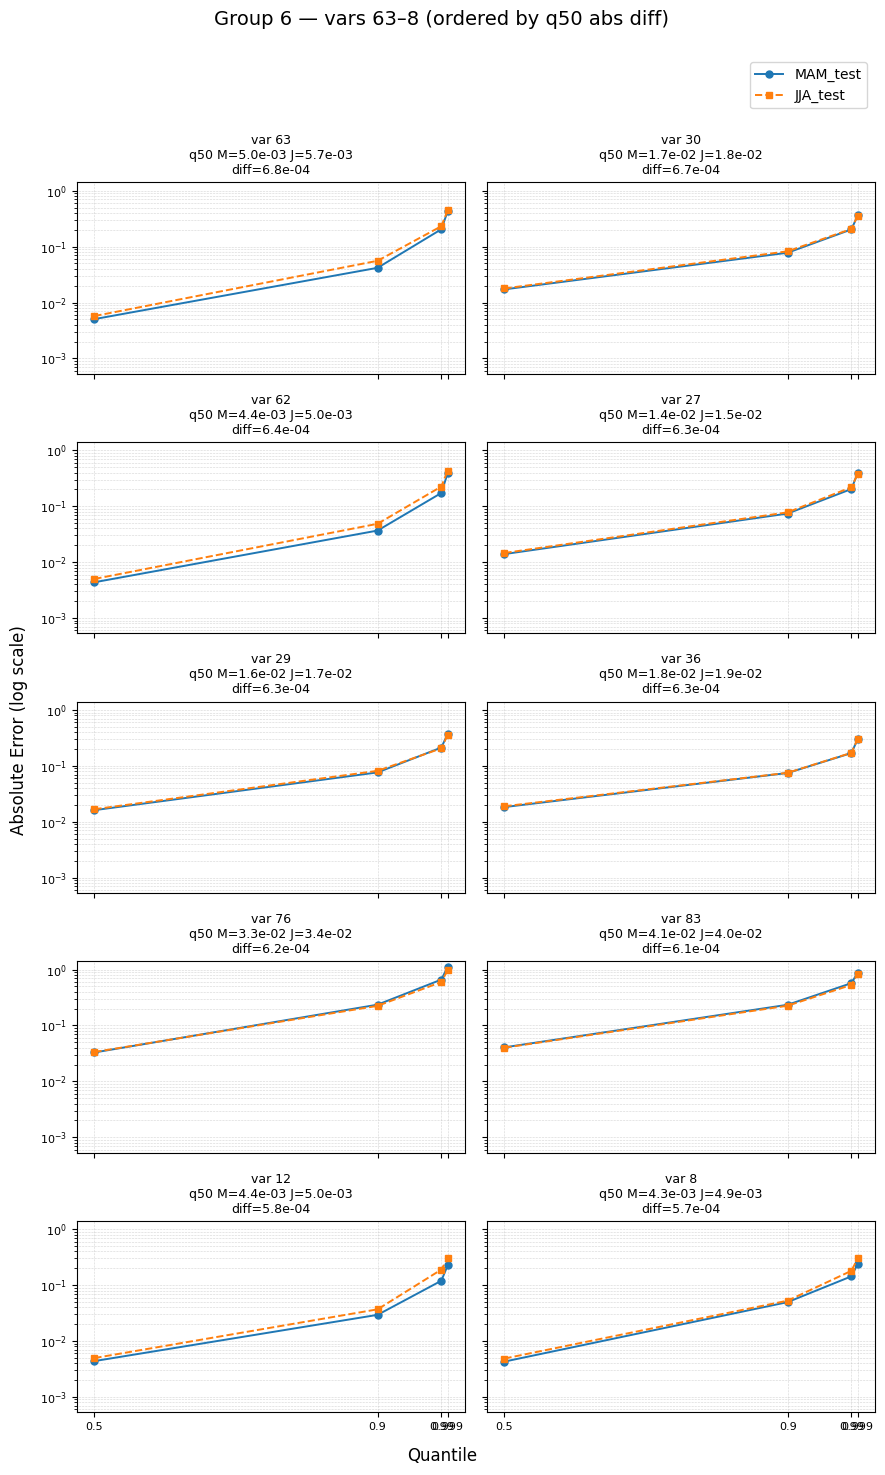

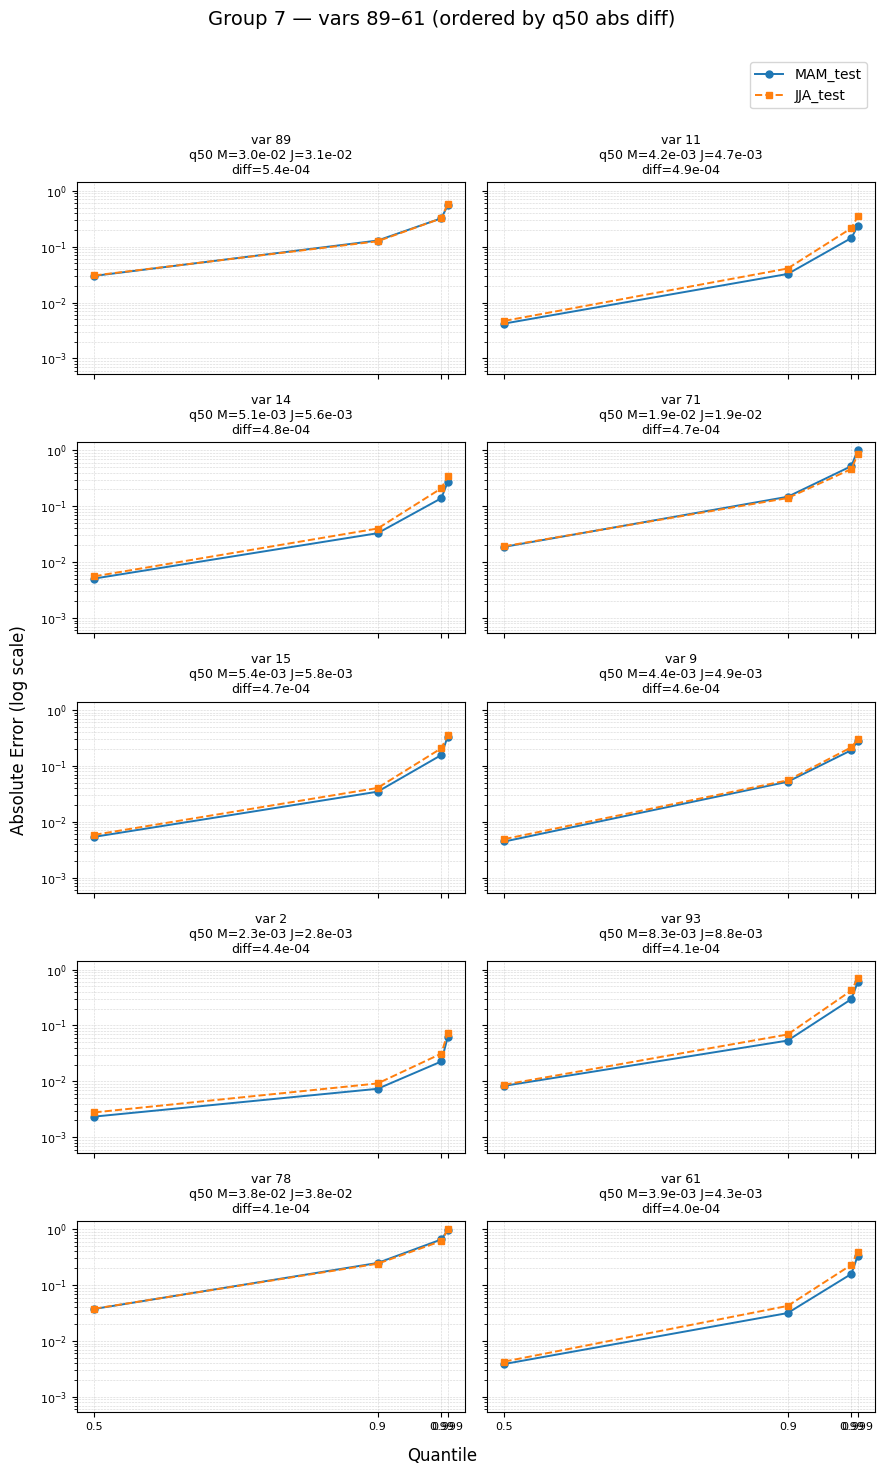

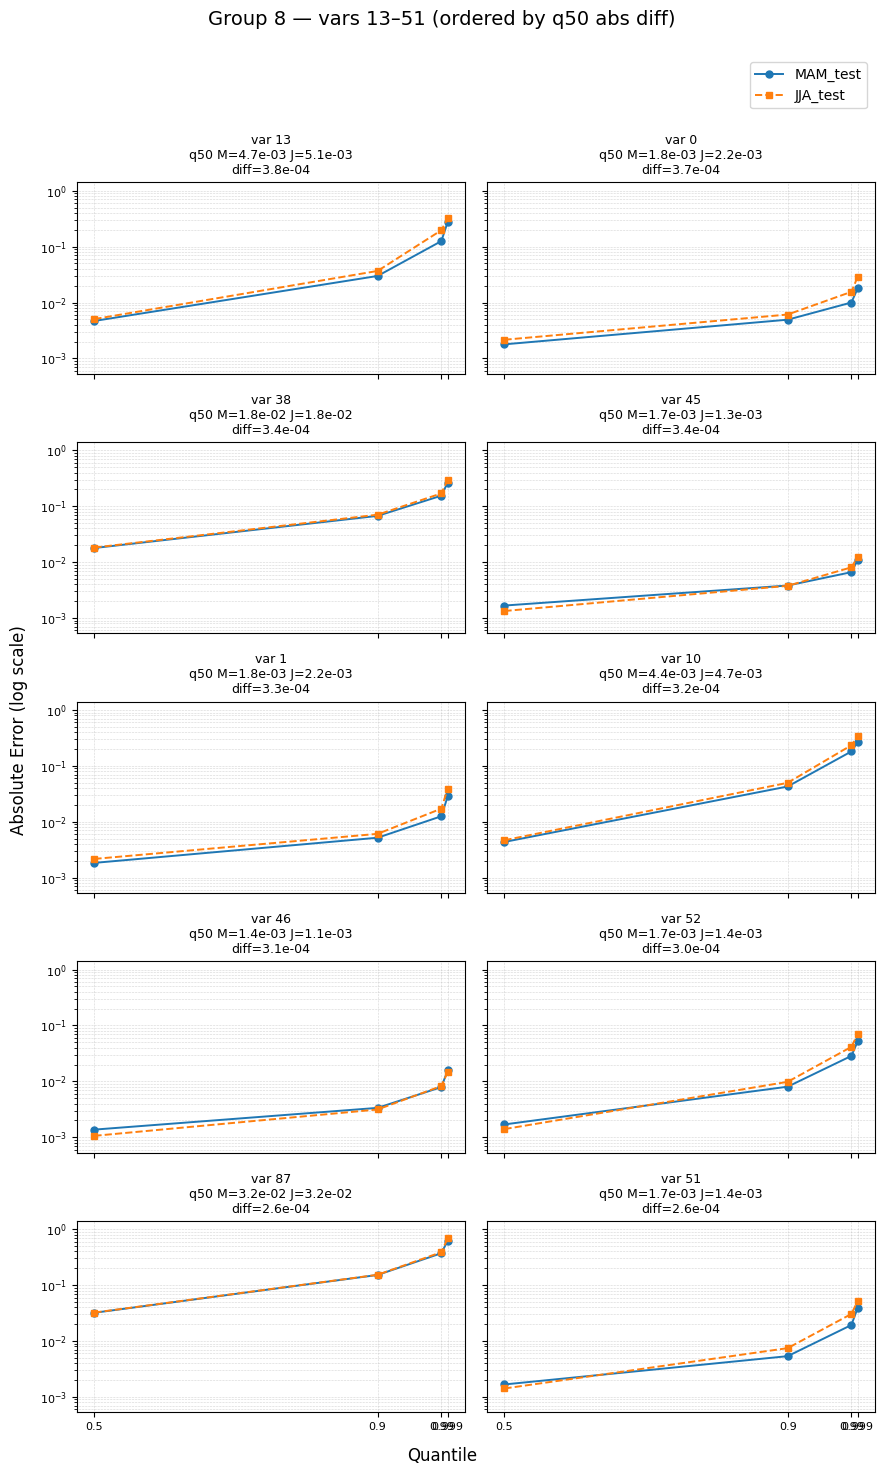

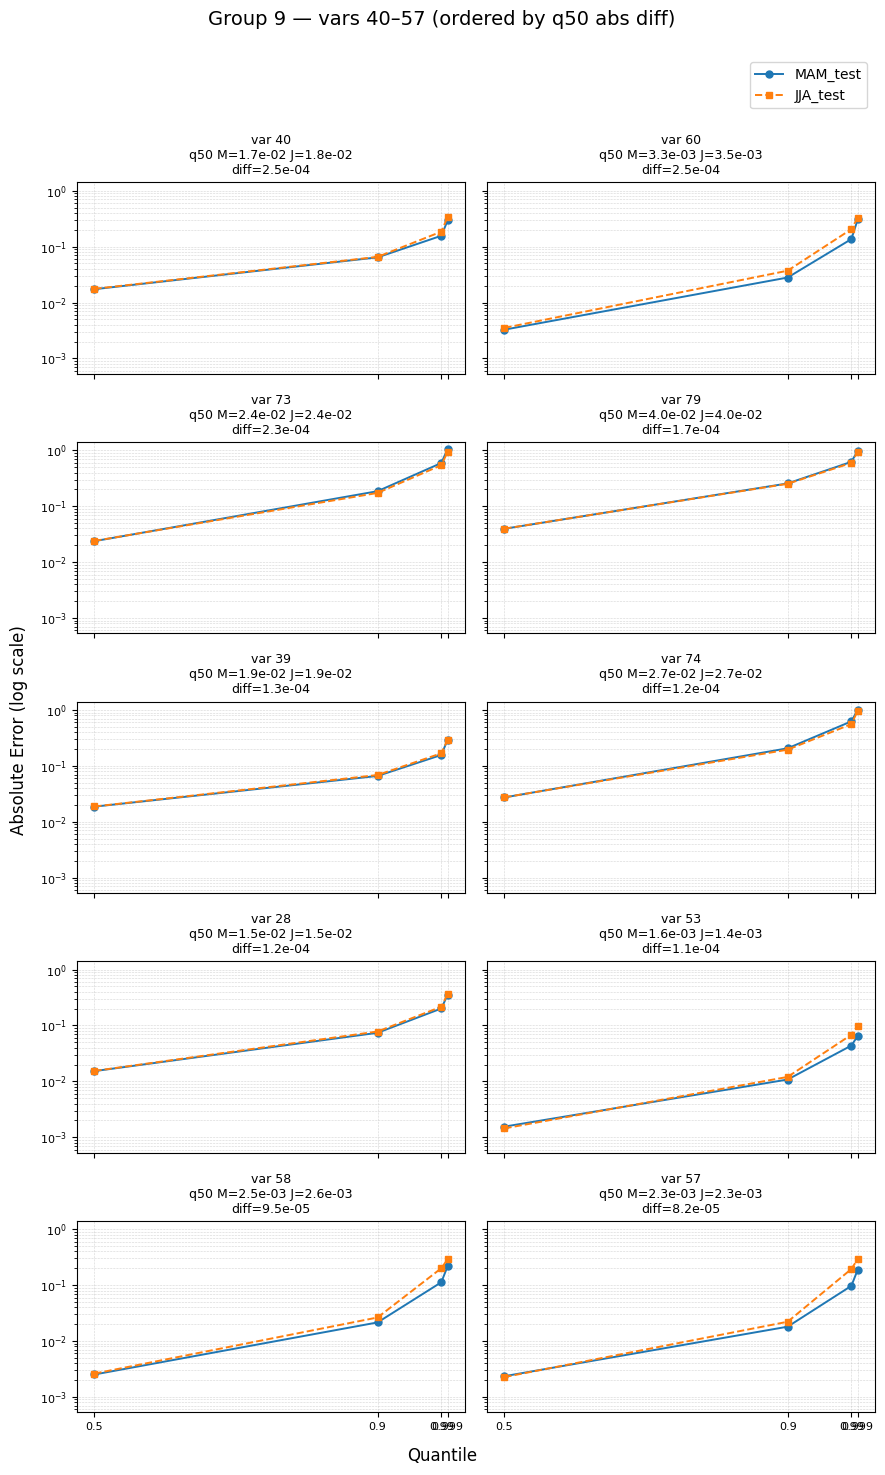

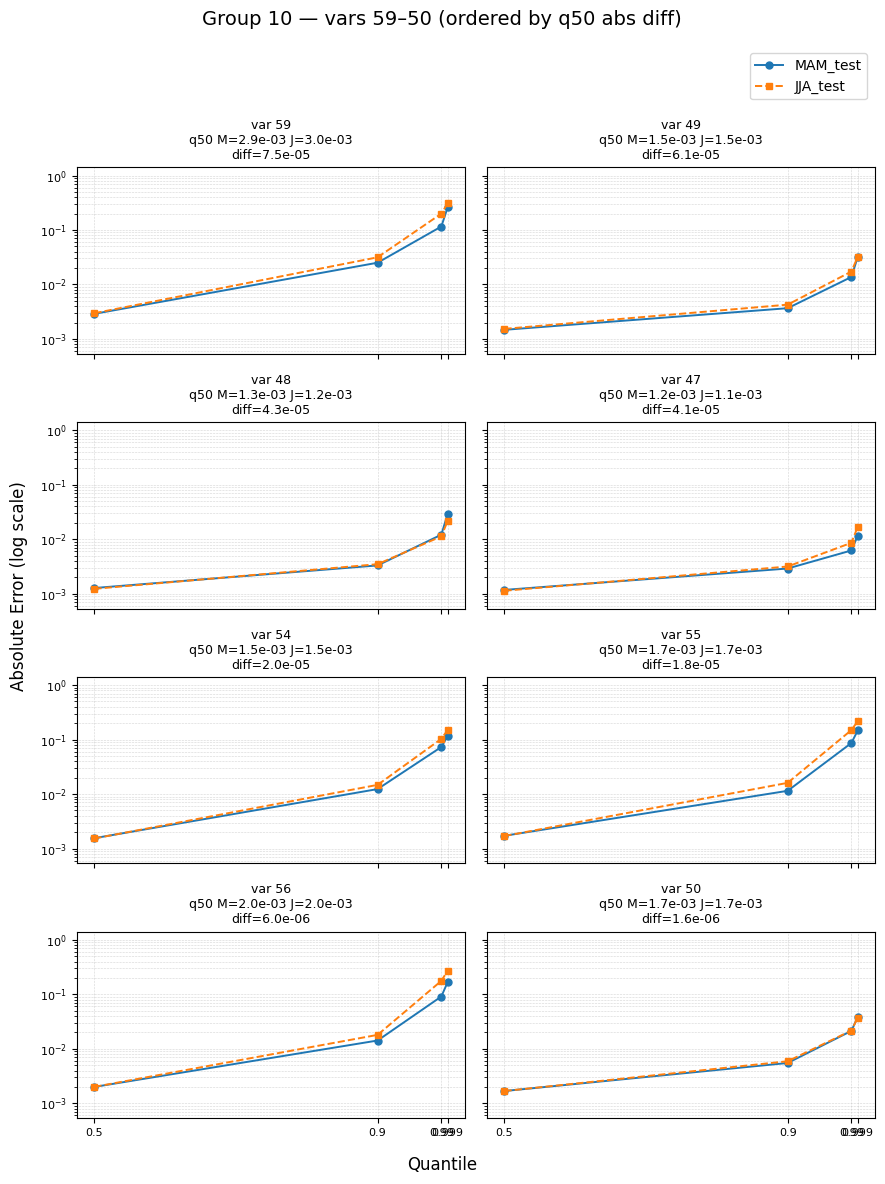

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ---------- User params ----------
quantiles = [0.5, 0.9, 0.99, 0.999]   # quantiles to display
markersize = 5
# use absolute q50 difference for ordering (set signed_diff = True to use JJA-MAM instead)
signed_diff = False
# ----------------------------------

# load arrays (nsamps, nvar)
preds_jja = results['JJA_test']['predictions'].cpu().numpy()
targs_jja = results['JJA_test']['targets'].cpu().numpy()
preds_mam = results['MAM_test']['predictions'].cpu().numpy()
targs_mam = results['MAM_test']['targets'].cpu().numpy()

nsamps, nvar = preds_jja.shape
assert nvar == preds_mam.shape[1] == targs_jja.shape[1] == targs_mam.shape[1], "Mismatch in variable count"

# compute quantiles per variable (absolute errors)
qvals_jja = np.zeros((nvar, len(quantiles)))
qvals_mam = np.zeros((nvar, len(quantiles)))
for i in range(nvar):
    qvals_jja[i, :] = np.quantile(np.abs(preds_jja[:, i] - targs_jja[:, i]), quantiles)
    qvals_mam[i, :] = np.quantile(np.abs(preds_mam[:, i] - targs_mam[:, i]), quantiles)

# compute q50 for each season
q50_idx = quantiles.index(0.5)
q50_jja = qvals_jja[:, q50_idx]
q50_mam = qvals_mam[:, q50_idx]

# sorting key: absolute difference by default, or signed difference if requested
if signed_diff:
    sort_key = q50_jja - q50_mam  # positive => JJA larger
    order = np.argsort(-sort_key)  # largest positive first
else:
    sort_key = np.abs(q50_jja - q50_mam)
    order = np.argsort(-sort_key)  # largest absolute difference first

# prepare groups: nine groups of 10, final group remainder
group_sizes = [10]*9 + [nvar - 90]
assert sum(group_sizes) == nvar

# global y-limits using all quantile values
all_qvals = np.concatenate([qvals_jja.flatten(), qvals_mam.flatten()])
positive_q = all_qvals[all_qvals > 0]
ymin = positive_q.min() * 0.5 if positive_q.size else 1e-12
ymax = all_qvals.max() * 1.1

x = quantiles
start = 0

for fig_idx, gsize in enumerate(group_sizes):
    vars_idx = order[start:start + gsize]
    start += gsize

    ncols = 2
    nrows = math.ceil(gsize / ncols)
    figsize = (9, nrows * 3.0)  # tweak if you want bigger panels

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax_i, var_i in enumerate(vars_idx):
        ax = axes[ax_i]

        ax.plot(x, qvals_mam[var_i], marker='o', linestyle='-', linewidth=1.4,
                markersize=markersize, label='MAM_test')
        ax.plot(x, qvals_jja[var_i], marker='s', linestyle='--', linewidth=1.4,
                markersize=markersize, label='JJA_test')

        ax.set_yscale('log')
        ax.set_ylim(ymin, ymax)
        ax.set_xticks(x)
        ax.set_xticklabels([str(q) for q in quantiles], fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, which='both', linestyle=':', linewidth=0.4)

        diff_val = (q50_jja[var_i] - q50_mam[var_i]) if signed_diff else np.abs(q50_jja[var_i] - q50_mam[var_i])
        ax.set_title(
            f'var {var_i}\nq50 M={q50_mam[var_i]:.1e} J={q50_jja[var_i]:.1e}\ndiff={diff_val:.1e}',
            fontsize=9
        )

    # hide unused axes
    for ax in axes[gsize:]:
        ax.axis('off')

    # shared labels + legend
    fig.supxlabel('Quantile', fontsize=12)
    fig.supylabel('Absolute Error (log scale)', fontsize=12)
    # get legend from first used axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95))

    fig.suptitle(f'Group {fig_idx+1} — vars {vars_idx[0]}–{vars_idx[-1]} (ordered by q50 {"signed diff" if signed_diff else "abs diff"})',
                 fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
